# Kernel moment–SoS hierarchy for global minimisation: a benchmark of Sections 4–5

Self-contained notebook for the global-minimisation part of the paper (Sections 4 and 5). The weight is the
Gaussian $\omega(x)=e^{-\|x\|^2/2}$ throughout (so $\omega^{-2}=e^{\|x\|^2}$ and $a_k=1/k!$ in **(W)**), except in
experiment 6. The objective is $f=\omega^2q$ with $q$ a polynomial, the partial-Taylor datum is
$\theta_d=\sum_{k\le d}\|x\|^{2k}/k!$, and the unknown is the moment vector $y$ of the tilted measure
$\nu=\omega^2\mu$. For a truncation order $d$ and a relaxation order $n\ge d$ we solve

$$\rho_{d,n}=\min_y\big\{L_y(q):\ L_y(\theta_d)=1,\ M_n(y)\succeq0,\ M_{n-d_j}(g_jy)\succeq0\big\},$$

which is (14a) of the paper; $\rho_d=\rho_{d,d}$ is (10b), written as the SDP (11b). The dual value $\lambda_{d,n}$ is read from the multiplier
of the normalisation $L_y(\theta_d)=1$. We compare with the surrogate $f^\star_d=\min_{\mathcal{X}}q/\theta_d$ (14b) and with
$f^\star=\min_{\mathcal{X}}f$, both computed by a dense grid followed by local refinement (L-BFGS-B).

| # | experiment | statements tested |
|---|---|---|
| 1 | convergence and truncation error, 1-D and 2-D | Thm 8, Prop 6, Lemma 12 |
| 2 | flat truncation, extraction, validated lower bound | Thm 10, Thm 13, Prop 7, Rem 4 |
| 3 | the counterexample of Rem 3 | Rem 3 |
| 4 | non-compact carrier $\mathcal{X}=\mathbb R^p$, tightness (T) | Prop 9 |
| 5 | general objectives, two approximation errors | Prop 14 |
| 6 | a weight with $\omega^{-2}$ polynomial | Thm 10 (exact case) |

Figures are written to `../figs/extra/g1_*.pdf`. Seeds are fixed and every solver status is recorded and printed.

**Numerical conventions.** The SDPs are written in the monomial basis, in the scaled variable $u=x/s$ with $s$ the
half-width of the smallest centred box containing $\mathcal{X}$, so that $|u^\alpha|\le1$ on $\mathcal{X}/s$. This is an exact
linear change of moment coordinates ($y_\alpha(x)=s^{|\alpha|}y_\alpha(u)$): values and ranks are unchanged, and the
moments stay of order one, which is what makes degree $2n=28$ (1-D) and $2n=18$ (2-D) solvable in double precision.
(Scaling by the radius $\sqrt2$ of the ball constraint instead of the half-width $1$ of the square costs about three
digits on the 2-D problems in a preliminary run.) Solver: Clarabel through cvxpy, with SCS as fallback when Clarabel
fails. Numerical ranks use a relative threshold `RANK_TOL` on the singular values.

In [1]:
import itertools, math, os, time, warnings, platform
import numpy as np
import scipy, scipy.sparse as sp, scipy.optimize as so
from scipy.linalg import schur
from numpy.polynomial import chebyshev as Cheb
import cvxpy as cp
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker

T_START = time.time()
print("python", platform.python_version(), "| numpy", np.__version__, "| scipy", scipy.__version__,
      "| cvxpy", cp.__version__, "| matplotlib", matplotlib.__version__)
print("cvxpy solvers:", cp.installed_solvers())

FIGDIR = "../figs/extra"
os.makedirs(FIGDIR, exist_ok=True)
PNGDIR = os.environ.get("G1_PNGDIR")      # optional PNG copies (for inspection only)
SEED = 0
RANK_TOL = 1e-4        # relative singular-value threshold for numerical ranks
TOL_CHECK = 1e-6       # slack in the inequality checks on SDP values (Clarabel accuracy is ~1e-8 to 1e-6 here)
NGRID = {1: 200001, 2: 801}

COL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]   # fixed categorical order (blue, orange, aqua, yellow)
GREY = "#6b6a66"
MARK = ["o", "s", "^", "D"]
plt.rcParams.update({"font.size": 9, "axes.titlesize": 9, "axes.labelsize": 9, "legend.fontsize": 7.5,
                     "lines.linewidth": 1.5, "lines.markersize": 4, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 110})

def savefig(fig, name):
    fig.savefig(os.path.join(FIGDIR, name + ".pdf"), bbox_inches="tight")
    if PNGDIR:
        os.makedirs(PNGDIR, exist_ok=True)
        fig.savefig(os.path.join(PNGDIR, name + ".png"), bbox_inches="tight", dpi=130)
    print("saved", os.path.join(FIGDIR, name + ".pdf"))

python 3.13.3 | numpy 2.3.3 | scipy 1.16.1 | cvxpy 1.9.1 | matplotlib 3.10.6
cvxpy solvers: ['CLARABEL', 'SCS', 'SCIPY', 'HIGHS', 'OSQP']


## 1. Helpers

Polynomials are dictionaries `{exponent tuple: coefficient}`. A weight is given by its coefficients $a_k$ in
$\omega^{-2}=\sum_k a_k\|x\|^{2k}$ and by $\omega^2$ as a function of $\|x\|^2$. Since
$\|x\|^{2k}=\sum_{|\beta|=k}\frac{k!}{\beta!}x^{2\beta}$, the datum is $\theta_d=\sum_{|\beta|\le d}a_{|\beta|}\frac{|\beta|!}{\beta!}x^{2\beta}$
(for the Gaussian, $\theta_d=\sum_{|\beta|\le d}x^{2\beta}/\beta!$).

In [2]:
# ---------------------------------------------------------------- weights
GAUSS  = dict(name="Gaussian", a=lambda k: math.exp(-math.lgamma(k + 1)), om2=lambda r2: np.exp(-r2))
CAUCHY = dict(name="Cauchy",   a=lambda k: 1.0 if k <= 1 else 0.0,        om2=lambda r2: 1.0 / (1.0 + r2))

# ---------------------------------------------------------------- monomials and polynomials
_MON = {}
def monos(p, D):
    # exponents alpha in N^p with |alpha| <= D (graded order) and their index
    if (p, D) not in _MON:
        out = []
        for t in range(D + 1):
            for c in itertools.combinations_with_replacement(range(p), t):
                a = [0] * p
                for i in c:
                    a[i] += 1
                out.append(tuple(a))
        _MON[(p, D)] = (out, {a: i for i, a in enumerate(out)})
    return _MON[(p, D)]

def pdeg(P):
    return max((sum(a) for a, c in P.items() if c != 0), default=0)

def peval(P, X):
    X = np.atleast_2d(X)
    v = np.zeros(X.shape[0])
    for a, c in P.items():
        v = v + c * np.prod(X ** np.array(a), axis=1)
    return v

def pscale(P, s):
    # P(s u) as a polynomial in u
    return {a: c * s ** sum(a) for a, c in P.items()}

def theta(p, d, W=GAUSS):
    mon, _ = monos(p, d)
    out = {}
    for beta in mon:
        k = sum(beta)
        c = W["a"](k) * math.factorial(k) / math.prod(math.factorial(b) for b in beta)
        if c != 0.0:
            out[tuple(2 * b for b in beta)] = c
    return out

def sqnorm(X):
    return np.sum(np.atleast_2d(X) ** 2, axis=1)

def omega2(X, W=GAUSS):
    return W["om2"](sqnorm(X))

def theta_eval(X, d, W=GAUSS):
    r2 = sqnorm(X)
    return sum(W["a"](k) * r2 ** k for k in range(d + 1))

def poisson_tail(r2, d):
    # P(Poisson(r2) > d) = 1 - omega^2 theta_d at ||x||^2 = r2 (Gaussian), computed without cancellation
    r2 = np.atleast_1d(r2).astype(float)
    return np.array([math.fsum(math.exp(-t + k * math.log(t) - math.lgamma(k + 1)) for k in range(d + 1, d + 160))
                     if t > 0 else 0.0 for t in r2])

def taylor_tail(R2, d, W=GAUSS):
    # sum_{k>d} a_k R2^k = sup_{||x||^2 <= R2} (omega^{-2} - theta_d): the bound on eps_d of Lemma 12 under (W)
    return math.fsum(W["a"](k) * R2 ** k for k in range(d + 1, d + 160))

def eps_d(R2, d, W=GAUSS):
    # eps_d = max_X (1 - omega^2 theta_d) (Proposition 7), for X reaching the radius R, R2 = max_X ||x||^2.
    # 1 - omega^2 theta_d = sum_{k>d} a_k r^k / sum_k a_k r^k is nondecreasing in r = ||x||^2, so
    # eps_d = omega^2(R) sum_{k>d} a_k R2^k: P(Poisson(R2) > d) for GAUSS; R2/(1+R2) at d = 0 and 0 for d >= 1 for CAUCHY
    if W["name"] == "Gaussian":
        return float(poisson_tail(R2, d)[0])
    return float(W["om2"](R2)) * taylor_tail(R2, d, W)

def eps_lemma(R2, d):
    # explicit bound of Lemma 12 (Gaussian): eps_d <= P(Poisson(R2) > d) <= R2^{d+1}/(d+1)!
    return math.exp((d + 1) * math.log(R2) - math.lgamma(d + 2))

def e_loc(X, d):
    # 1/theta_d - omega^2 >= 0 on R^p (Gaussian): the pointwise surrogate error per unit of |q|
    return poisson_tail(sqnorm(X), d) / theta_eval(X, d)

# ---------------------------------------------------------------- moment and localizing operators
def loc_op(p, n, g):
    # sparse A with vec(M_{n-d_g}(g y)) = A @ y, y indexed by monos(p, 2n)
    k = n - math.ceil(pdeg(g) / 2)
    rows, _ = monos(p, k)
    _, idx = monos(p, 2 * n)
    N = len(rows)
    I, J, V = [], [], []
    for i, a in enumerate(rows):
        for j, b in enumerate(rows):
            for gam, c in g.items():
                I.append(i * N + j); J.append(idx[tuple(x + y + z for x, y, z in zip(a, b, gam))]); V.append(c)
    return sp.csr_matrix((V, (I, J)), shape=(N * N, len(idx))), N

def lin(p, n, P):
    # coefficient vector c with L_y(P) = c @ y
    _, idx = monos(p, 2 * n)
    c = np.zeros(len(idx))
    for a, v in P.items():
        c[idx[a]] += v
    return c

def mom_mat(yv, p, t):
    rows, _ = monos(p, t)
    D = 0
    while len(monos(p, D)[0]) < len(yv):
        D += 1
    _, idx = monos(p, D)
    return np.array([[yv[idx[tuple(x + y for x, y in zip(a, b))]] for b in rows] for a in rows])

def sqnorm_moments(yv, p, n, d):
    # a_k L_y(||x||^{2k}) for k = 0..d (x-coordinates are recovered from u = x/s by the caller)
    return np.array([lin(p, n, {e: c for e, c in theta(p, k).items() if sum(e) == 2 * k}) @ yv for k in range(d + 1)])

# ---------------------------------------------------------------- the relaxation rho_{d,n}
def solve_relax(q, gs, p, d, n, s=1.0, W=GAUSS, solvers=("CLARABEL", "SCS")):
    # rho_{d,n} = min { L_y(q) : L_y(theta_d)=1, M_n(y) >= 0, M_{n-d_j}(g_j y) >= 0 }, in u = x/s
    assert n >= d and 2 * n >= pdeg(q)
    th, qs, gss = pscale(theta(p, d, W), s), pscale(q, s), [pscale(g, s) for g in gs]
    m = len(monos(p, 2 * n)[0])
    y = cp.Variable(m)
    cons = [lin(p, n, th) @ y == 1]
    ops = []
    for g in [{(0,) * p: 1.0}] + gss:
        A, N = loc_op(p, n, g)
        Me = cp.reshape(A @ y, (N, N), order="C")
        cons.append((Me + Me.T) / 2 >> 0)
        ops.append((A, N))
    prob = cp.Problem(cp.Minimize(lin(p, n, qs) @ y), cons)
    out = dict(status="not solved", solver=None, value=np.nan, lam=np.nan, y=None, s=s, p=p, d=d, n=n, tries=[])
    t0 = time.time()
    for sol in solvers:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")      # the status is recorded below instead
                if sol == "SCS":
                    prob.solve(solver=sol, eps=1e-9, max_iters=100000)
                else:
                    prob.solve(solver=sol)
            out["tries"].append((sol, prob.status))
            out.update(status=prob.status, solver=sol)
            if prob.status in ("optimal", "optimal_inaccurate"):
                break
        except cp.error.SolverError:
            out["tries"].append((sol, "solver_error"))
            out.update(status="solver_error", solver=sol)
    out["time"] = time.time() - t0
    if out["status"] in ("optimal", "optimal_inaccurate") and y.value is not None:
        out["value"] = float(prob.value)
        out["y"] = y.value.copy()
        out["lam"] = -float(cons[0].dual_value)      # cvxpy sign convention for the equality multiplier
        r = lin(p, n, qs) - out["lam"] * lin(p, n, th)
        mineig = []
        for (A, N), c in zip(ops, cons[1:]):
            Z = np.asarray(c.dual_value)
            r = r - A.T @ Z.reshape(-1)
            mineig.append((float(np.linalg.eigvalsh((Z + Z.T) / 2).min()), N))
        out["dual_res"] = r            # coefficients of q - lam theta_d - sum_j g_j sigma_j (u-coordinates)
        out["mineig"] = mineig
    return out

def certified_shift(out, gmax):
    # sup_X |residual| <= sum|r_alpha| + sum_j max(0,-eigmin Z_j) N_j sup_X|g_j|  (|u^alpha| <= 1 on X/s)
    c = float(np.abs(out["dual_res"]).sum())
    for (e, N), gm in zip(out["mineig"], [1.0] + list(gmax)):
        c += max(0.0, -e) * N * gm
    return c

# ---------------------------------------------------------------- ranks and extraction
def svals(M):
    return np.linalg.svd((M + M.T) / 2, compute_uv=False)

def num_rank(M, tol=RANK_TOL):
    sv = svals(M)
    if sv[0] <= 0:
        return 0, sv
    return int(np.sum(sv > tol * sv[0])), sv

def flat_truncation(yv, p, n, d0=1, tol=RANK_TOL):
    # smallest t <= n with rank M_{t-d0}(y) = rank M_t(y)  (eq. flat at depth d0)
    for t in range(d0, n + 1):
        r0, _ = num_rank(mom_mat(yv, p, t - d0), tol)
        r1, sv = num_rank(mom_mat(yv, p, t), tol)
        if r0 == r1 and r1 >= 1:
            gap = sv[r1 - 1] / sv[r1] if r1 < len(sv) and sv[r1] > 0 else np.inf
            return t, r1, gap
    return None, None, None

def extract_atoms(yv, p, t, r, seed=SEED):
    # Henrion-Lasserre extraction from a flat M_t(y) of rank r (u-coordinates): atoms (r,p), weights (r,)
    if r is None or r < 1 or t < 1:
        return None, None
    rows, idx_t = monos(p, t)
    M = mom_mat(yv, p, t)
    U, S, _ = np.linalg.svd((M + M.T) / 2)
    V = U[:, :r] * np.sqrt(S[:r])
    piv, Qb = [], np.zeros((0, r))
    scale = np.linalg.norm(V, axis=1).max()
    for i in range(len(rows)):                    # column echelon form: greedy pivots in graded order
        v = V[i] - Qb.T @ (Qb @ V[i])
        if np.linalg.norm(v) > 1e-6 * scale:
            piv.append(i); Qb = np.vstack([Qb, v / np.linalg.norm(v)])
        if len(piv) == r:
            break
    basis = [rows[i] for i in piv]
    if len(piv) < r or max(sum(w) for w in basis) > t - 1:
        return None, None
    Uech = V @ np.linalg.inv(V[piv, :])
    Ns = []
    for i in range(p):
        e = [0] * p; e[i] = 1
        Ns.append(np.array([Uech[idx_t[tuple(b + ee for b, ee in zip(w, e))], :] for w in basis]))
    c = np.random.default_rng(seed).random(p); c /= c.sum()
    _, Q = schur(sum(ci * Ni for ci, Ni in zip(c, Ns)), output="real")
    atoms = np.array([[Q[:, j] @ Ns[i] @ Q[:, j] for i in range(p)] for j in range(r)])
    mon_t, _ = monos(p, t)
    Vm = np.array([[np.prod(x ** np.array(a)) for x in atoms] for a in mon_t])
    w, *_ = np.linalg.lstsq(Vm, yv[: len(mon_t)], rcond=None)
    return atoms, w

def gap_rank(M, floor=1e-12):
    # numerical rank at the largest ratio s_i/s_{i+1} among singular values above floor*s_0
    sv = svals(M)
    k = int(np.sum(sv > floor * sv[0]))
    if k <= 1:
        return k
    ratios = sv[:k - 1] / sv[1:k]
    return int(np.argmax(ratios)) + 1 if ratios.max() > 1e2 else k

def moment_residual(yv, p, t, atoms_u, w):
    # relative residual of sum_i w_i v_{2t}(x_i) against the moments of degree <= 2t (u-coordinates)
    mon, _ = monos(p, 2 * t)
    Vm = np.array([[np.prod(x ** np.array(a)) for x in atoms_u] for a in mon])
    return float(np.linalg.norm(Vm @ w - yv[:len(mon)]) / np.linalg.norm(yv[:len(mon)]))

def hausdorff(A, B):
    D = np.linalg.norm(np.asarray(A)[:, None, :] - np.asarray(B)[None, :, :], axis=2)
    return max(D.min(axis=1).max(), D.min(axis=0).max())

# ---------------------------------------------------------------- reference global minimisation on a box
def grid_minimisers(fun, lo, hi, npts, tol=1e-8, maxcand=40):
    # dense grid, discrete local minima, L-BFGS-B refinement; returns f*, argmin set, all local minima
    lo, hi = np.asarray(lo, float), np.asarray(hi, float)
    p = len(lo)
    axes = [np.linspace(lo[i], hi[i], npts) for i in range(p)]
    if p == 1:
        G = axes[0][:, None]; V = fun(G)
        loc = [i for i in range(npts) if (i == 0 or V[i] <= V[i - 1]) and (i == npts - 1 or V[i] <= V[i + 1])]
        cand = G[loc]
    else:
        A, B = np.meshgrid(axes[0], axes[1], indexing="ij")
        V = fun(np.column_stack([A.ravel(), B.ravel()])).reshape(npts, npts)
        Vp = np.pad(V, 1, constant_values=np.inf)
        ismin = np.ones_like(V, dtype=bool)
        for di in (-1, 0, 1):
            for dj in (-1, 0, 1):
                if di or dj:
                    ismin &= V <= Vp[1 + di:1 + di + npts, 1 + dj:1 + dj + npts]
        ii, jj = np.nonzero(ismin)
        cand = np.column_stack([axes[0][ii], axes[1][jj]])
    vals = fun(cand)
    locs = []
    for x0 in cand[np.argsort(vals)[:maxcand]]:
        r = so.minimize(lambda z: fun(z[None, :])[0], x0, method="L-BFGS-B", bounds=list(zip(lo, hi)),
                        options=dict(ftol=1e-16, gtol=1e-13, maxiter=5000))
        x, v = (r.x, r.fun) if r.fun <= fun(x0[None, :])[0] else (x0, fun(x0[None, :])[0])
        if all(np.linalg.norm(x - z) > 1e-4 for z, _ in locs):
            locs.append((x, float(v)))
    locs.sort(key=lambda t: t[1])
    fstar = locs[0][1]
    arg = np.array([x for x, v in locs if v <= fstar + tol * max(1.0, abs(fstar))])
    return fstar, arg, locs

def fmt_status(r):
    return "/".join("%s:%s" % (s[:3], st.replace("optimal_inaccurate", "opt_inacc")) for s, st in r["tries"])
print("helpers loaded")

helpers loaded


## 2. Test problems

Compact carriers, each described with the ball constraint $R^2-\|x\|^2\ge0$ among the $g_j$ as in Theorem 8:

* 1-D, $\mathcal{X}=[-1.5,1.5]=\{2.25-x^2\ge0\}$ ($R^2=2.25$):
  * `1d-multi`: $q=x^6-3x^4+2x^2+0.6x$, three local minima of $f$, the global one at $x^\star\approx-1.146$;
  * `1d-two`: $q=x^4-2x^2$, two global minimisers $\pm0.765$;
  * `1d-bdry`: $q=2-x$, $f^\star>0$ attained on the boundary $x^\star=1.5$.
* 2-D, $\mathcal{X}=[-1,1]^2=\{1-x_1^2\ge0,\ 1-x_2^2\ge0,\ 2-\|x\|^2\ge0\}$ ($R^2=2$):
  * `2d-camel`: $q$ = six-hump camel $(4-2.1x_1^2+x_1^4/3)x_1^2+x_1x_2+(4x_2^2-4)x_2^2$, two global minimisers and
    boundary local minima;
  * `2d-four`: $q=x_1^4+x_2^4+\tfrac12x_1^2x_2^2-1.5(x_1^2+x_2^2)$, four global minimisers;
  * `2d-bdry`: $q=3-x_1-x_2$, $f^\star=e^{-2}>0$ attained at the vertex $(1,1)$.

In [3]:
CAMEL = {(2, 0): 4.0, (4, 0): -2.1, (6, 0): 1 / 3, (1, 1): 1.0, (0, 2): -4.0, (0, 4): 4.0}
FOUR  = {(4, 0): 1.0, (0, 4): 1.0, (2, 2): 0.5, (2, 0): -1.5, (0, 2): -1.5}
BALL1 = [{(0,): 2.25, (2,): -1.0}]
BOX2  = [{(0, 0): 1.0, (2, 0): -1.0}, {(0, 0): 1.0, (0, 2): -1.0}, {(0, 0): 2.0, (2, 0): -1.0, (0, 2): -1.0}]
PROBLEMS = [
    dict(key="1d-multi", p=1, q={(6,): 1.0, (4,): -3.0, (2,): 2.0, (1,): 0.6}, lo=[-1.5], hi=[1.5], R2=2.25, gs=BALL1, dmax=12, dn=2),
    dict(key="1d-two",   p=1, q={(4,): 1.0, (2,): -2.0},                      lo=[-1.5], hi=[1.5], R2=2.25, gs=BALL1, dmax=12, dn=2),
    dict(key="1d-bdry",  p=1, q={(0,): 2.0, (1,): -1.0},                      lo=[-1.5], hi=[1.5], R2=2.25, gs=BALL1, dmax=12, dn=2),
    dict(key="2d-camel", p=2, q=CAMEL,                                        lo=[-1, -1], hi=[1, 1], R2=2.0, gs=BOX2, dmax=8, dn=1),
    dict(key="2d-four",  p=2, q=FOUR,                                         lo=[-1, -1], hi=[1, 1], R2=2.0, gs=BOX2, dmax=8, dn=1),
    dict(key="2d-bdry",  p=2, q={(0, 0): 3.0, (1, 0): -1.0, (0, 1): -1.0},    lo=[-1, -1], hi=[1, 1], R2=2.0, gs=BOX2, dmax=8, dn=1),
]
t0 = time.time()
for P in PROBLEMS:
    q, p = P["q"], P["p"]
    P["dmin"] = max(1, math.ceil(pdeg(q) / 2))
    P["s"] = float(max(np.max(np.abs(P["lo"])), np.max(np.abs(P["hi"]))))   # half-width of the box
    P["fstar"], P["argmin"], P["locmins"] = grid_minimisers(lambda X: omega2(X) * peval(q, X), P["lo"], P["hi"], NGRID[p])
    axes = [np.linspace(P["lo"][i], P["hi"][i], 1001 if p == 1 else 401) for i in range(p)]
    G = np.array(list(itertools.product(*axes)))
    P["qinf"] = float(np.abs(peval(q, G)).max())
    P["gmax"] = [float(np.abs(peval(g, G)).max()) for g in P["gs"]]
    P["min_om2th"] = lambda d, G=G: float((omega2(G) * theta_eval(G, d)).min())
    print("%-9s f* = %+.10f  argmin = %s  ||q||_inf = %.3f" % (P["key"], P["fstar"], np.round(P["argmin"], 5).tolist(), P["qinf"]))
    print("          local minima of f:", [(np.round(x, 3).tolist(), round(v, 4)) for x, v in P["locmins"][:6]])
print("reference minimisation: %.1f s" % (time.time() - t0))

1d-multi  f* = -0.2609020770  argmin = [[-1.14557]]  ||q||_inf = 1.603
          local minima of f: [([-1.146], -0.2609), ([-0.158], -0.0456), ([1.272], 0.0756)]
1d-two    f* = -0.4611587920  argmin = [[-0.76537], [0.76537]]  ||q||_inf = 1.000
          local minima of f: [([-0.765], -0.4612), ([0.765], -0.4612)]
1d-bdry   f* = +0.0526996123  argmin = [[1.5]]  ||q||_inf = 3.500
          local minima of f: [([1.5], 0.0527), ([-1.5], 0.3689)]


2d-camel  f* = -0.6576586306  argmin = [[0.06263, -0.6205], [-0.06263, 0.6205]]  ||q||_inf = 3.233
          local minima of f: [([0.063, -0.62], -0.6577), ([-0.063, 0.62], -0.6577), ([1.0, -0.801], 0.0993), ([-1.0, 0.801], 0.0993), ([-1.0, -0.84], 0.4074), ([1.0, 0.84], 0.4074)]
2d-four   f* = -0.3712160303  argmin = [[-0.56478, -0.56478], [0.56478, 0.56478], [-0.56478, 0.56478], [0.56478, -0.56478]]  ||q||_inf = 0.900
          local minima of f: [([-0.565, -0.565], -0.3712), ([0.565, 0.565], -0.3712), ([-0.565, 0.565], -0.3712), ([0.565, -0.565], -0.3712)]


2d-bdry   f* = +0.1353352832  argmin = [[1.0, 1.0]]  ||q||_inf = 5.000
          local minima of f: [([1.0, 1.0], 0.1353), ([-1.0, 1.0], 0.406), ([1.0, -1.0], 0.406), ([-1.0, -1.0], 0.6767)]
reference minimisation: 0.6 s


saved ../figs/extra/g1_problems.pdf


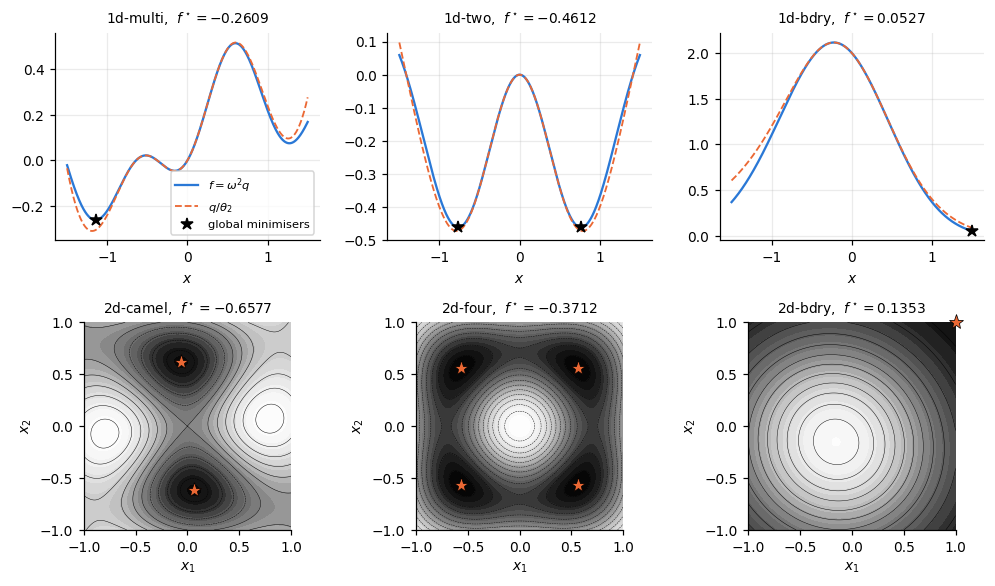

In [4]:
fig, axs = plt.subplots(2, 3, figsize=(9.2, 5.4))
for ax, P in zip(axs.ravel(), PROBLEMS):
    q = P["q"]
    if P["p"] == 1:
        x = np.linspace(P["lo"][0], P["hi"][0], 1201)[:, None]
        ax.plot(x[:, 0], omega2(x) * peval(q, x), color=COL[0], label=r"$f=\omega^2q$")
        ax.plot(x[:, 0], peval(q, x) / theta_eval(x, 2), color=COL[1], ls="--", lw=1.2, label=r"$q/\theta_2$")
        ax.plot(P["argmin"][:, 0], [P["fstar"]] * len(P["argmin"]), "k*", ms=8, label="global minimisers")
        ax.set_xlabel("$x$")
    else:
        g = np.linspace(-1, 1, 301); A, B = np.meshgrid(g, g, indexing="ij")
        F = (omega2(np.column_stack([A.ravel(), B.ravel()])) * peval(q, np.column_stack([A.ravel(), B.ravel()]))).reshape(A.shape)
        ax.contourf(A, B, F, levels=24, cmap="Greys_r", zorder=-1)
        ax.set_rasterization_zorder(0)            # keeps the PDF small
        ax.contour(A, B, F, levels=12, colors="k", linewidths=0.3)
        ax.plot(P["argmin"][:, 0], P["argmin"][:, 1], "*", color=COL[1], ms=10, mec="k", mew=0.5, clip_on=False, zorder=5)
        ax.set_aspect("equal"); ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.grid(False)
    ax.set_title("%s,  $f^\\star=%.4f$" % (P["key"], P["fstar"]))
axs[0, 0].legend(loc="lower right")
fig.tight_layout()
savefig(fig, "g1_problems")
plt.show()

## 3. Experiment 1: convergence of $\rho_d$ and the truncation error

For each problem and each $d$ we compute $f^\star_d$ (grid and refinement) and $\rho_{d,n}$ for $n=d,\dots,d+\Delta$
($\Delta=2$ in 1-D, $1$ in 2-D). Statements checked:

* $\rho_{d,n}\le f^\star_d$ (relaxation of (14b)) and $n\mapsto\rho_{d,n}$ nondecreasing;
* $\lambda_{d}=\rho_d$ (Proposition 6), read from the dual multiplier;
* $\rho_d\to f^\star$ (Theorem 8);
* Lemma 12: $|f^\star_d-f^\star|\le\max_{x\in\{x^\star,x_d\}}|q(x)|\,(1-\omega^2\theta_d)(x)\le\|q\|_{\infty,\mathcal{X}}\varepsilon_d$, where $x^\star$
  minimises $f$ and $x_d$ minimises $q/\theta_d$, $\varepsilon_d=\max_{\mathcal{X}}(1-\omega^2\theta_d)\le\sum_{k>d}a_kR^{2k}$, and, for the
  Gaussian, $\varepsilon_d\le\mathbb P(\mathrm{Poisson}(R^2)>d)\le R^{2(d+1)}/(d+1)!$.

Under **(W)**, $1-\omega^2\theta_d=\sum_{k>d}a_kr^k/\sum_ka_kr^k$ is nondecreasing in $r=\|x\|^2$, and both carriers reach the
radius $R$ (at $\pm1.5$ and at the corners of the square). So `eps_d` returns $\varepsilon_d=\mathbb P(\mathrm{Poisson}(R^2)>d)$
exactly, and the check also compares it with the maximum of $1-\omega^2\theta_d$ on the grid of $\mathcal{X}$.

Two further quantities are printed. The first is the monotonicity of $d\mapsto f^\star_d$ stated after (14b): $\theta_d\uparrow\omega^{-2}$,
so $f^\star<0$ gives $f^\star_d\uparrow f^\star$ and $f^\star>0$ gives $f^\star_d\downarrow f^\star$. The second, `local.est`, is the localised
bound of Lemma 12 before its proof drops the factor $1/\theta_d\le1$:
$$|f^\star_d-f^\star|\le\max_{x\in\{x^\star,x_d\}}|q(x)|\,e_d(x),\qquad e_d(x)=\frac1{\theta_d(x)}-\omega^2(x)=\frac{\mathbb P(\mathrm{Poisson}(\|x\|^2)>d)}{\theta_d(x)}\le\frac{\|x\|^{2(d+1)}}{(d+1)!}.$$
It shows that the rate is governed by $\|x^\star\|$ rather than by $R$.

In [5]:
RUNS, SUR = {}, {}
t0 = time.time()
for P in PROBLEMS:
    q, p, key = P["q"], P["p"], P["key"]
    fun_f = lambda X: omega2(X) * peval(q, X)
    print("\n== %s  (f* = %+.10f, R^2 = %.2f, ||q|| = %.2f)" % (key, P["fstar"], P["R2"], P["qinf"]))
    print("  d   eps_d     |fd-f*|   ||q||eps_d  local.est  " + "  ".join("rho(d,d+%d)-fd" % k for k in range(P["dn"] + 1))
          + "   lam-rho    status")
    for d in range(P["dmin"], P["dmax"] + 1):
        fd, argd, _ = grid_minimisers(lambda X: peval(q, X) / theta_eval(X, d), P["lo"], P["hi"], NGRID[p])
        loc = max(max(abs(peval(q, x[None, :])[0]) * e_loc(x[None, :], d)[0] for x in P["argmin"]),
                  max(abs(peval(q, x[None, :])[0]) * e_loc(x[None, :], d)[0] for x in argd))
        loc12 = max(abs(peval(q, x[None, :])[0]) * poisson_tail(sqnorm(x[None, :]), d)[0] for x in list(P["argmin"]) + list(argd))
        SUR[key, d] = dict(fd=fd, argd=argd, loc=loc, loc12=loc12)     # loc12: localised bound of Lemma 12
        cols, sts = [], []
        for n in range(d, d + P["dn"] + 1):
            r = solve_relax(q, P["gs"], p, d, n, s=P["s"])
            RUNS[key, d, n] = r
            cols.append("%+11.2e" % (r["value"] - fd)); sts.append(fmt_status(r))
        r0 = RUNS[key, d, d]
        print("%3d  %8.2e  %9.2e  %9.2e  %9.2e  %s   %+8.1e   %s" % (d, eps_d(P["R2"], d), abs(fd - P["fstar"]),
              P["qinf"] * eps_d(P["R2"], d), loc, "   ".join(cols), r0["lam"] - r0["value"], " ".join(sorted(set(sts)))))
print("\nexperiment 1: %.1f s, %d SDPs" % (time.time() - t0, len(RUNS)))


== 1d-multi  (f* = -0.2609020770, R^2 = 2.25, ||q|| = 1.60)
  d   eps_d     |fd-f*|   ||q||eps_d  local.est  rho(d,d+0)-fd  rho(d,d+1)-fd  rho(d,d+2)-fd   lam-rho    status


  3  1.91e-01   1.26e-02   3.06e-01   1.32e-02    -1.63e-08     -5.96e-09     -2.07e-10   +4.9e-09   CLA:optimal
  4  7.80e-02   2.97e-03   1.25e-01   3.02e-03    +9.28e-10     -4.28e-10     +7.54e-09   -1.7e-10   CLA:opt_inacc CLA:optimal
  5  2.74e-02   6.14e-04   4.39e-02   6.18e-04    +5.38e-09     +1.62e-08     -4.84e-08   +2.6e-09   CLA:opt_inacc CLA:optimal


  6  8.37e-03   1.12e-04   1.34e-02   1.12e-04    +6.48e-09     -2.28e-07     -1.43e-07   +4.1e-09   CLA:opt_inacc


  7  2.27e-03   1.79e-05   3.63e-03   1.79e-05    -2.51e-07     -2.86e-07     -4.55e-07   +1.7e-08   CLA:opt_inacc
  8  5.50e-04   2.57e-06   8.82e-04   2.57e-06    -2.74e-07     -4.55e-07     -6.18e-07   +2.1e-08   CLA:opt_inacc


  9  1.21e-04   3.32e-07   1.94e-04   3.32e-07    -4.55e-07     -3.52e-07     -3.38e-07   +3.6e-08   CLA:opt_inacc


...

  3  1.43e-01   2.26e-02   7.14e-01   2.26e-02    -4.15e-10     -2.14e-09   +3.2e-12   CLA:optimal
  4  5.27e-02   7.52e-03   2.63e-01   7.52e-03    -2.03e-09     +8.56e-08   +4.1e-10   CLA:opt_inacc CLA:optimal


  5  1.66e-02   2.28e-03   8.28e-02   2.28e-03    +7.74e-08     +9.98e-08   +1.5e-08   CLA:opt_inacc


  6  4.53e-03   6.16e-04   2.27e-02   6.16e-04    +8.23e-08     +1.21e-07   +3.2e-09   CLA:opt_inacc


  7  1.10e-03   1.49e-04   5.48e-03   1.49e-04    +1.15e-07     +6.76e-07   +4.6e-09   CLA:opt_inacc


  8  2.37e-04   3.21e-05   1.19e-03   3.21e-05    +6.69e-07     +2.52e-06   +1.5e-08   CLA:opt_inacc

experiment 1: 48.7 s, 141 SDPs


In [6]:
def check(name, ok, detail=""):
    CHECKS.append((name, bool(ok), detail))
    print("[%s] %s %s" % ("pass" if ok else "FAIL", name, detail))
CHECKS = []
for P in PROBLEMS:
    key, fs, R2 = P["key"], P["fstar"], P["R2"]
    ds = range(P["dmin"], P["dmax"] + 1)
    tol = TOL_CHECK * max(1.0, abs(fs))
    sol_ok = all(RUNS[key, d, n]["status"] in ("optimal", "optimal_inaccurate") for d in ds for n in range(d, d + P["dn"] + 1))
    viol_rel = max(RUNS[key, d, n]["value"] - SUR[key, d]["fd"] for d in ds for n in range(d, d + P["dn"] + 1))
    viol_mon = max(RUNS[key, d, n]["value"] - RUNS[key, d, n + 1]["value"] for d in ds for n in range(d, d + P["dn"]))
    fdv = np.array([SUR[key, d]["fd"] for d in ds])
    mono = np.all(np.diff(fdv) >= -1e-12) if fs < 0 else np.all(np.diff(fdv) <= 1e-12)
    gap = max(abs(RUNS[key, d, d]["lam"] - RUNS[key, d, d]["value"]) for d in ds)
    # Lemma 12: |f*_d - f*| <= max_{x in {x*, x_d}} |q(x)| (1 - omega^2 theta_d)(x) <= ||q|| eps_d, eps_d <= sum_{k>d} a_k R^{2k},
    # and for the Gaussian eps_d <= P(Poisson(R^2) > d) <= R^{2(d+1)}/(d+1)!; eps_d is also compared with the grid of X
    epsg = max(abs(eps_d(R2, d) - (1 - P["min_om2th"](d))) for d in ds)
    tay = epsg <= 1e-12 and all(abs(SUR[key, d]["fd"] - fs) <= SUR[key, d]["loc12"] * (1 + 1e-6) + 1e-13
                                and SUR[key, d]["loc12"] <= P["qinf"] * eps_d(R2, d)
                                and eps_d(R2, d) <= min(taylor_tail(R2, d), eps_lemma(R2, d)) * (1 + 1e-12) for d in ds)
    pess = [P["qinf"] * eps_d(R2, d) / abs(SUR[key, d]["fd"] - fs) for d in ds]
    locv = all(abs(SUR[key, d]["fd"] - fs) <= SUR[key, d]["loc"] * (1 + 1e-6) + 1e-13 for d in ds)
    last = abs(RUNS[key, P["dmax"], P["dmax"]]["value"] - fs)
    print("--", key)
    check("all SDPs solved", sol_ok)
    check("rho_{d,n} <= f*_d", viol_rel <= tol, "(max excess %.1e)" % viol_rel)
    check("rho_{d,n} nondecreasing in n", viol_mon <= tol, "(max decrease %.1e)" % viol_mon)
    check("f*_d monotone in d (direction = sign f*)", mono)
    check("lambda_d = rho_d", gap <= 1e-5 * max(1, abs(fs)), "(max |lambda-rho| %.1e)" % gap)
    check("Lemma 12: |f*_d-f*| <= localised bound <= ||q|| eps_d, eps_d <= tail sum and <= R^{2(d+1)}/(d+1)!", tay,
          "(max |eps_d - max_grid(1-om^2 theta_d)| %.0e)" % epsg)
    check("localised estimate holds", locv)
    print("   |rho_d - f*| at d = %d: %.2e ;  ||q|| eps_d / |f*_d-f*| from %.1e to %.1e" % (P["dmax"], last, min(pess), max(pess)))

-- 1d-multi
[pass] all SDPs solved 
[pass] rho_{d,n} <= f*_d (max excess 1.6e-08)
[pass] rho_{d,n} nondecreasing in n (max decrease 2.3e-07)
[pass] f*_d monotone in d (direction = sign f*) 
[pass] lambda_d = rho_d (max |lambda-rho| 4.4e-08)
[pass] Lemma 12: |f*_d-f*| <= localised bound <= ||q|| eps_d, eps_d <= tail sum and <= R^{2(d+1)}/(d+1)! (max |eps_d - max_grid(1-om^2 theta_d)| 4e-16)
[pass] localised estimate holds 
   |rho_d - f*| at d = 12: 6.58e-07 ;  ||q|| eps_d / |f*_d-f*| from 2.4e+01 to 2.9e+03
-- 1d-two
[pass] all SDPs solved 
[pass] rho_{d,n} <= f*_d (max excess -2.9e-10)
[pass] rho_{d,n} nondecreasing in n (max decrease 4.9e-08)
[pass] f*_d monotone in d (direction = sign f*) 
[pass] lambda_d = rho_d (max |lambda-rho| 3.1e-08)
[pass] Lemma 12: |f*_d-f*| <= localised bound <= ||q|| eps_d, eps_d <= tail sum and <= R^{2(d+1)}/(d+1)! (max |eps_d - max_grid(1-om^2 theta_d)| 4e-16)
[pass] localised estimate holds 
   |rho_d - f*| at d = 12: 1.79e-07 ;  ||q|| eps_d / |f*_d-f*|

-- 2d-bdry
[pass] all SDPs solved 
[FAIL] rho_{d,n} <= f*_d (max excess 2.5e-06)
[pass] rho_{d,n} nondecreasing in n (max decrease 1.7e-09)
[pass] f*_d monotone in d (direction = sign f*) 
[pass] lambda_d = rho_d (max |lambda-rho| 1.5e-08)
[pass] Lemma 12: |f*_d-f*| <= localised bound <= ||q|| eps_d, eps_d <= tail sum and <= R^{2(d+1)}/(d+1)! (max |eps_d - max_grid(1-om^2 theta_d)| 3e-16)
[pass] localised estimate holds 
   |rho_d - f*| at d = 8: 3.28e-05 ;  ||q|| eps_d / |f*_d-f*| from 1.5e+01 to 3.7e+01


saved ../figs/extra/g1_convergence.pdf


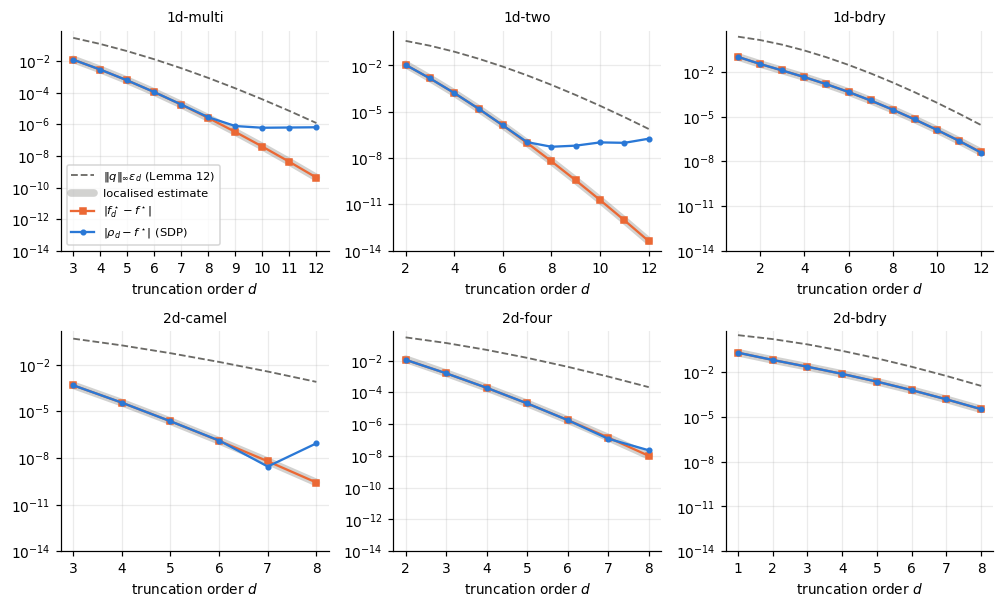

In [7]:
fig, axs = plt.subplots(2, 3, figsize=(9.2, 5.6), sharey=False)
for ax, P in zip(axs.ravel(), PROBLEMS):
    key, fs, R2 = P["key"], P["fstar"], P["R2"]
    ds = np.arange(P["dmin"], P["dmax"] + 1)
    ax.semilogy(ds, [P["qinf"] * eps_d(R2, d) for d in ds], color=GREY, ls="--", lw=1.2, label=r"$\|q\|_\infty\varepsilon_d$ (Lemma 12)")
    ax.semilogy(ds, [SUR[key, d]["loc"] for d in ds], color=GREY, lw=5, alpha=0.3, solid_capstyle="round", label="localised estimate")
    ax.semilogy(ds, [max(abs(SUR[key, d]["fd"] - fs), 1e-16) for d in ds], color=COL[1], marker="s", label=r"$|f^\star_d-f^\star|$")
    ax.semilogy(ds, [max(abs(RUNS[key, d, d]["value"] - fs), 1e-16) for d in ds], color=COL[0], marker="o", ms=3, label=r"$|\rho_d-f^\star|$ (SDP)")
    ax.set_title(key); ax.set_xlabel("truncation order $d$")
    ax.set_ylim(1e-14, None); ax.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))
axs[0, 0].legend(loc="lower left")
fig.tight_layout()
savefig(fig, "g1_convergence")
plt.show()

## 4. Experiment 2: flat truncation, extraction and the validated lower bound

For every solved $\rho_{d,n}$ we look for the smallest $t\le n$ with $\operatorname{rank}M_{t-1}(y^\star)=\operatorname{rank}M_t(y^\star)$
($d_0=1$, all $g_j$ quadratic), extract the atoms $x_i$ and weights $a_i$ of $\nu^\star$, and record:

* `H(f)`, `H(sur)`: Hausdorff distance between the atoms and $\arg\min f$, resp. $\arg\min q/\theta_d$;
* `contact`: $\max_i|q(x_i)-\lambda_d\theta_d(x_i)|$ (Remark 4);
* `|f-lam|/(|lam|eps)`: the ratio $\max_i|f(x_i)-\lambda_d|/(|\lambda_d|\varepsilon_d)$, at most $1$ by the proof of Theorem 10;
* `mass-1`: $\sum_ia_i\,\omega^{-2}(x_i)-1$, the mass defect of $\mu^\star=\omega^{-2}\nu^\star$ ($0$ only if $\theta_d=\omega^{-2}$);
* the lower bounds of Proposition 7: `LB` $=\min_{\mathcal{X}}(\lambda_d\omega^2\theta_d)$, `LBeps` $=\lambda_d(1-\varepsilon_d)$ or $\lambda_d$,
  and `LBcert` $=$ `LB` minus a bound on the certificate residual (coefficients of
  $q-\lambda_d\theta_d-\sum_jg_j\sigma_j$ and negative eigenvalues of the Gram matrices, in the scaled variable where
  $|u^\alpha|\le1$ on $\mathcal{X}$). `LBcert` $\le f^\star$ is guaranteed up to rounding in the residual.

In [8]:
EXT = {}
for P in PROBLEMS:
    key, p, q, fs, R2, s = P["key"], P["p"], P["q"], P["fstar"], P["R2"], P["s"]
    print("\n== %s" % key)
    print("  d  n  t  r   gap      H(f)      H(sur)   contact  |f-lam|/(|lam|eps)  mass-1     f*-LB     f*-LBeps   f*-LBcert")
    for d in range(P["dmin"], P["dmax"] + 1):
        for n in range(d, d + P["dn"] + 1):
            r = RUNS[key, d, n]
            e = dict(t=None)
            if r["y"] is not None:
                t, rk, gap = flat_truncation(r["y"], p, n)
                lam = r["lam"]; epsd = eps_d(R2, d)
                mn = P["min_om2th"](d)
                LB = lam * mn if lam >= 0 else lam * 1.0          # max of omega^2 theta_d on X is 1 (x = 0 in X)
                LBeps = lam * (1 - epsd) if lam >= 0 else lam
                LBcert = LB - certified_shift(r, P["gmax"])
                e.update(t=t, r=rk, gap=gap, LB=LB, LBeps=LBeps, LBcert=LBcert)
                if t is not None:
                    at, w = extract_atoms(r["y"], p, t, rk)
                    if at is not None:
                        at = at * s
                        e.update(atoms=at, w=w, Hf=hausdorff(at, P["argmin"]), Hs=hausdorff(at, SUR[key, d]["argd"]),
                                 contact=float(np.abs(peval(q, at) - lam * theta_eval(at, d)).max()),
                                 ratio=float(np.abs(omega2(at) * peval(q, at) - lam).max() / (abs(lam) * epsd)),
                                 dev=float(np.abs(omega2(at) * peval(q, at) - lam).max()), bnd=abs(lam) * epsd,
                                 mass=float(np.sum(w / omega2(at)) - 1), inX=bool(np.all([peval(g, at) >= -1e-6 for g in P["gs"]])),
                                 res=moment_residual(r["y"], p, t, at / s, w))
            EXT[key, d, n] = e
            if "atoms" in e:
                print("%3d %2d %2d %2d  %7.1e  %8.1e  %8.1e  %8.1e  %10.2e       %+8.1e  %+9.2e  %+9.2e  %+9.2e" % (
                    d, n, e["t"], e["r"], e["gap"], e["Hf"], e["Hs"], e["contact"], e["ratio"], e["mass"],
                    fs - e["LB"], fs - e["LBeps"], fs - e["LBcert"]))
            else:
                print("%3d %2d  no flat truncation or extraction failed (t=%s)   f*-LB %+9.2e  f*-LBcert %+9.2e" % (
                    d, n, e.get("t"), fs - e.get("LB", np.nan), fs - e.get("LBcert", np.nan)))


== 1d-multi
  d  n  t  r   gap      H(f)      H(sur)   contact  |f-lam|/(|lam|eps)  mass-1     f*-LB     f*-LBeps   f*-LBcert
  3  3  1  1  3.6e+07   1.6e-02   2.6e-05   4.7e-08    2.53e-01       +5.1e-02  +1.26e-02  +1.26e-02  +1.26e-02
  3  4  1  1  1.3e+07   1.6e-02   1.9e-05   1.3e-08    2.53e-01       +5.1e-02  +1.26e-02  +1.26e-02  +1.26e-02
  3  5  1  1  1.7e+08   1.6e-02   2.1e-05   2.4e-09    2.53e-01       +5.1e-02  +1.26e-02  +1.26e-02  +1.26e-02
  4  4  1  1  4.3e+07   5.0e-03   1.7e-05   5.3e-10    1.47e-01       +1.2e-02  +2.97e-03  +2.97e-03  +2.97e-03
  4  5  1  1  4.4e+08   5.0e-03   1.7e-05   4.6e-10    1.47e-01       +1.2e-02  +2.97e-03  +2.97e-03  +2.97e-03
  4  6  1  1  1.4e+07   4.9e-03   6.2e-05   9.5e-09    1.47e-01       +1.2e-02  +2.97e-03  +2.97e-03  +2.97e-03
  5  5  1  1  4.3e+07   1.3e-03   3.8e-05   1.8e-08    8.63e-02       +2.4e-03  +6.14e-04  +6.14e-04  +6.14e-04
  5  6  1  1  1.3e+07   1.2e-03   6.8e-05   3.1e-08    8.63e-02       +2.4e-03  +6.14e-04

  9 10  1  1  5.4e+08   1.2e-04   1.2e-04   1.4e-06    2.23e-02       +9.1e-07  +6.74e-07  +6.74e-07  +6.44e-06
  9 11  1  1  2.2e+07   9.0e-05   8.9e-05   1.2e-06    2.10e-02       +1.1e-06  +6.47e-07  +6.47e-07  +4.57e-06
 10 10  1  1  2.2e+07   1.2e-04   1.2e-04   2.1e-06    9.53e-02       -5.1e-08  +5.72e-07  +5.72e-07  +6.78e-06
 10 11  1  1  1.3e+07   1.2e-04   1.2e-04   2.3e-06    1.04e-01       -1.8e-07  +6.26e-07  +6.26e-07  +7.86e-06
 10 12  1  1  1.1e+07   9.6e-05   9.6e-05   2.4e-06    1.07e-01       -2.2e-07  +6.54e-07  +6.54e-07  +8.46e-06
 11 11  1  1  1.3e+07   1.2e-04   1.2e-04   2.3e-06    5.32e-01       -3.1e-07  +5.91e-07  +5.91e-07  +7.83e-06
 11 12  1  1  1.1e+07   9.6e-05   9.6e-05   2.4e-06    5.48e-01       -3.6e-07  +6.19e-07  +6.19e-07  +8.43e-06
 11 13  1  1  1.1e+07   9.0e-05   9.0e-05   2.3e-06    5.27e-01       -3.3e-07  +5.97e-07  +5.97e-07  +8.46e-06
 12 12  1  1  1.1e+07   9.6e-05   9.6e-05   2.4e-06    3.19e+00       -3.7e-07  +6.15e-07  +6.15e-07  +8

  4  5  3  4  2.3e+06   8.8e-04   5.2e-05   1.1e-07    9.97e-03       +5.2e-04  +1.94e-04  +1.94e-04  +1.96e-04
  5  5  3  4  2.2e+06   1.8e-04   7.8e-05   1.2e-07    3.30e-03       +5.4e-05  +2.02e-05  +2.02e-05  +2.24e-05


  5  6  3  4  1.8e+06   9.2e-06   1.1e-04   1.4e-09    3.28e-03       +5.4e-05  +2.02e-05  +2.02e-05  +2.37e-05
  6  6  3  4  2.5e+06   9.4e-05   1.1e-04   1.1e-08    1.08e-03       +4.8e-06  +1.81e-06  +1.81e-06  +4.81e-06
  6  7  3  4  6.0e+06   1.0e-04   1.1e-04   1.1e-08    1.08e-03       +4.9e-06  +1.81e-06  +1.81e-06  +4.18e-06
  7  7  3  4  6.0e+06   1.1e-04   1.1e-04   1.1e-08    3.66e-04       +3.8e-07  +1.33e-07  +1.33e-07  +2.51e-06
  7  8  3  4  2.6e+06   1.1e-04   1.1e-04   9.9e-09    3.39e-04       +3.1e-07  +1.22e-07  +1.22e-07  +3.82e-06
  8  8  3  4  2.6e+06   1.1e-04   1.1e-04   9.7e-09    5.60e-05       -4.9e-08  -1.17e-08  -1.17e-08  +3.68e-06
  8  9  3  4  4.0e+06   1.1e-04   1.1e-04   1.7e-08    1.21e-05       -1.5e-08  -1.54e-08  -1.54e-08  +3.71e-06

== 2d-bdry
  d  n  t  r   gap      H(f)      H(sur)   contact  |f-lam|/(|lam|eps)  mass-1     f*-LB     f*-LBeps   f*-LBcert
  1  1  1  1  9.0e+08   4.0e-09   4.0e-09   5.9e-09    1.00e+00       +1.5e+00  -4.73e-10 

  7  7  1  1  7.4e+06   1.5e-07   1.5e-07   2.4e-07    1.00e+00       +1.1e-03  -1.19e-07  -1.19e-07  +2.83e-06
  7  8  1  1  1.3e+06   8.0e-07   8.0e-07   1.7e-06    1.00e+00       +1.1e-03  -6.91e-07  -6.91e-07  +1.44e-05


  8  8  1  1  1.3e+06   7.9e-07   7.9e-07   1.7e-06    1.01e+00       +2.4e-04  -6.84e-07  -6.84e-07  +1.43e-05
  8  9  1  1  4.0e+05   3.0e-06   3.0e-06   5.8e-06    1.02e+00       +2.3e-04  -2.54e-06  -2.54e-06  +4.02e-05


In [9]:
for P in PROBLEMS:
    key, fs = P["key"], P["fstar"]
    items = [(k, v) for k, v in EXT.items() if k[0] == key]
    ext = [v for k, v in items if "atoms" in v]
    nflat_dd = sum(1 for k, v in items if k[1] == k[2] and "atoms" in v)
    ndd = sum(1 for k, v in items if k[1] == k[2])
    print("--", key, "| flat truncation found in %d/%d runs (%d/%d at n = d); smallest flat t: %s; ranks: %s" % (
        len(ext), len(items), nflat_dd, ndd, sorted(set(v["t"] for v in ext)), sorted(set(v["r"] for v in ext))))
    check("number of atoms = number of global minimisers", all(v["r"] == len(P["argmin"]) for v in ext))
    check("atoms in X", all(v["inX"] for v in ext))
    check("extracted measure reproduces the moments of degree <= 2t", all(v["res"] <= 1e-4 for v in ext), "(max rel. residual %.1e)" % max(v["res"] for v in ext))
    check("atoms = surrogate minimisers (H(sur) <= 1e-3)", all(v["Hs"] <= 1e-3 for v in ext), "(max %.1e)" % max(v["Hs"] for v in ext))
    # Theorem 10: |f(x_i)-lambda_d| = |lambda_d| (1 - omega^2 theta_d)(x_i) <= |lambda_d| eps_d, with equality at an atom of
    # largest norm; lambda_d and the atoms are known to solver accuracy, hence the slack TOL_CHECK as in the other checks
    tolf = TOL_CHECK * max(1.0, abs(fs))
    check("|f(x_i)-lambda_d| <= |lambda_d| eps_d + TOL_CHECK", all(v["dev"] <= v["bnd"] + tolf for v in ext),
          "(max ratio %.3g, max excess %+.1e, excess > 0 in %d of %d runs)" % (max(v["ratio"] for v in ext),
          max(v["dev"] - v["bnd"] for v in ext), sum(v["dev"] > v["bnd"] for v in ext), len(ext)))
    check("LB <= f* (Prop 7)", all(v["LB"] <= fs + TOL_CHECK for k, v in items if "LB" in v),
          "(max LB-f* %+.1e)" % max(v["LB"] - fs for k, v in items if "LB" in v))
    check("LBcert <= f*", all(v["LBcert"] <= fs for k, v in items if "LB" in v),
          "(max LBcert-f* %+.1e)" % max(v["LBcert"] - fs for k, v in items if "LB" in v))
    # Theorem 13: d(eps) = min{d : 2||q|| eps_d <= eps} versus the observed d
    for epsil in (1e-2, 1e-4):
        dth = next((d for d in range(P["dmin"], 60) if 2 * P["qinf"] * eps_d(P["R2"], d) <= epsil), None)
        dob = next((d for d in range(P["dmin"], P["dmax"] + 1) if "atoms" in EXT[key, d, d]
                    and np.max(omega2(EXT[key, d, d]["atoms"]) * peval(P["q"], EXT[key, d, d]["atoms"])) - fs <= epsil), None)
        print("   accuracy %.0e: d(eps) of Thm 13 = %s, observed smallest d with f(x_i)-f* <= eps: %s" % (epsil, dth, dob))

-- 1d-multi | flat truncation found in 30/30 runs (10/10 at n = d); smallest flat t: [1]; ranks: [1]
[pass] number of atoms = number of global minimisers 
[pass] atoms in X 
[pass] extracted measure reproduces the moments of degree <= 2t (max rel. residual 9.9e-08)
[pass] atoms = surrogate minimisers (H(sur) <= 1e-3) (max 1.4e-04)
[pass] |f(x_i)-lambda_d| <= |lambda_d| eps_d + TOL_CHECK (max ratio 3.19, max excess +4.4e-07, excess > 0 in 3 of 30 runs)
[pass] LB <= f* (Prop 7) (max LB-f* -5.7e-07)
[pass] LBcert <= f* (max LBcert-f* -4.6e-06)
   accuracy 1e-02: d(eps) of Thm 13 = 7, observed smallest d with f(x_i)-f* <= eps: 3
   accuracy 1e-04: d(eps) of Thm 13 = 10, observed smallest d with f(x_i)-f* <= eps: 4
-- 1d-two | flat truncation found in 33/33 runs (11/11 at n = d); smallest flat t: [2]; ranks: [2]
[pass] number of atoms = number of global minimisers 
[pass] atoms in X 
[pass] extracted measure reproduces the moments of degree <= 2t (max rel. residual 4.7e-08)
[pass] atoms = s

**Non-isolated minimisers.** Theorem 10 is conditional on (12), and Theorem 13 assumes isolated minimisers. With
$q=\|x\|^4-2\|x\|^2$ on $[-1,1]^2$ (same constraints as above), $f=e^{-t}(t^2-2t)$ with $t=\|x\|^2$ is minimised on the whole circle
$t=2-\sqrt2$, and so is $q/\theta_d$ (on the circle $t=t_d$). A measure on a circle has $\operatorname{rank}M_t=2t+1$, so no flat
truncation can exist; we check that the solver returns this rank pattern and that the value is nevertheless $f^\star_d$.
We print the numerical ranks for the relative threshold `RANK_TOL` and for a largest-gap rule, and run the extraction
whenever the threshold rule reports a flat truncation.

In [10]:
RING = {(4, 0): 1.0, (0, 4): 1.0, (2, 2): 2.0, (2, 0): -2.0, (0, 2): -2.0}
ts = np.linspace(0, 1, 2000001)                       # t = ||x||^2; the minimising circle lies inside the square
tstar = 2 - math.sqrt(2)
fsR = math.exp(-tstar) * (tstar ** 2 - 2 * tstar)
print("f* = %+.10f on the circle ||x||^2 = %.6f" % (fsR, tstar))
ring_nogapflat, ring_ok_val, spurious, ring_2t1, ring_runs = True, True, [], 0, 0
for d in range(2, 8):
    thd = sum(ts ** k / math.factorial(k) for k in range(d + 1))
    sur = (ts ** 2 - 2 * ts) / thd
    fdR, tdR = float(sur.min()), float(ts[np.argmin(sur)])
    for n in (d, d + 1):
        r = solve_relax(RING, BOX2, 2, d, n, s=1.0)
        ranks = [num_rank(mom_mat(r["y"], 2, t))[0] for t in range(n + 1)]
        granks = [gap_rank(mom_mat(r["y"], 2, t)) for t in range(n + 1)]
        tf, rk, _ = flat_truncation(r["y"], 2, n)
        ring_nogapflat &= all(granks[t - 1] != granks[t] for t in range(1, n + 1))
        ring_2t1 += all(granks[t] == 2 * t + 1 for t in range(n)); ring_runs += 1
        ring_ok_val &= abs(r["value"] - fdR) <= 1e-6
        msg = ""
        if tf is not None:
            at, w = extract_atoms(r["y"], 2, tf, rk)
            ok = at is not None and bool(np.all([peval(g, at) >= -1e-6 for g in BOX2]))
            res = moment_residual(r["y"], 2, tf, at, w) if at is not None else np.nan
            spurious.append((d, n, tf, rk, ok, res))
            msg = "  <- threshold rank flat at t=%d (r=%d): atoms in X: %s, moment residual %.1e" % (tf, rk, ok, res)
        print("d=%d n=%d  rho-f*_d = %+.1e  (f*_d-f* = %+.1e, t_d = %.5f)  rank M_t (threshold): %s  (largest gap): %s  %s%s" % (
              d, n, r["value"] - fdR, fdR - fsR, tdR, ranks, granks, fmt_status(r), msg))
check("ring: no flat truncation under the largest-gap rank rule", ring_nogapflat)
print("   largest-gap rank = 2t+1 for all t <= n-1 in %d of %d runs (the top blocks are the least accurate)" % (ring_2t1, ring_runs))
check("ring: every threshold-rank 'flat truncation' is rejected by the extraction sanity checks",
      all((not ok) or res > 1e-3 for _, _, _, _, ok, res in spurious), "(%d spurious cases)" % len(spurious))
check("ring: rho_{d,n} = f*_d although no flat truncation", ring_ok_val)

f* = -0.4611587920 on the circle ||x||^2 = 0.585786
d=2 n=2  rho-f*_d = -3.1e-09  (f*_d-f* = -1.1e-02, t_d = 0.61803)  rank M_t (threshold): [1, 3, 5]  (largest gap): [1, 3, 5]  CLA:optimal
d=2 n=3  rho-f*_d = -3.7e-09  (f*_d-f* = -1.1e-02, t_d = 0.61803)  rank M_t (threshold): [1, 3, 5, 7]  (largest gap): [1, 3, 5, 7]  CLA:optimal
d=3 n=3  rho-f*_d = -5.7e-09  (f*_d-f* = -1.5e-03, t_d = 0.59144)  rank M_t (threshold): [1, 3, 5, 7]  (largest gap): [1, 3, 5, 7]  CLA:opt_inacc
d=3 n=4  rho-f*_d = -2.9e-09  (f*_d-f* = -1.5e-03, t_d = 0.59144)  rank M_t (threshold): [1, 3, 5, 7, 9]  (largest gap): [1, 3, 5, 7, 9]  CLA:optimal


d=4 n=4  rho-f*_d = -6.7e-10  (f*_d-f* = -1.6e-04, t_d = 0.58659)  rank M_t (threshold): [1, 3, 5, 7, 9]  (largest gap): [1, 3, 5, 7, 9]  CLA:optimal


d=4 n=5  rho-f*_d = -4.7e-08  (f*_d-f* = -1.6e-04, t_d = 0.58659)  rank M_t (threshold): [1, 3, 5, 7, 9, 11]  (largest gap): [1, 3, 5, 7, 9, 11]  CLA:opt_inacc


d=5 n=5  rho-f*_d = -5.3e-08  (f*_d-f* = -1.6e-05, t_d = 0.58588)  rank M_t (threshold): [1, 3, 5, 7, 9, 11]  (largest gap): [1, 3, 5, 7, 9, 11]  CLA:opt_inacc


d=5 n=6  rho-f*_d = -8.2e-08  (f*_d-f* = -1.6e-05, t_d = 0.58588)  rank M_t (threshold): [1, 3, 5, 7, 9, 11, 11]  (largest gap): [1, 3, 5, 7, 9, 11, 13]  CLA:opt_inacc  <- threshold rank flat at t=6 (r=11): atoms in X: True, moment residual 3.2e-01


d=6 n=6  rho-f*_d = -8.0e-08  (f*_d-f* = -1.3e-06, t_d = 0.58580)  rank M_t (threshold): [1, 3, 5, 7, 9, 11, 11]  (largest gap): [1, 3, 5, 7, 9, 11, 13]  CLA:opt_inacc  <- threshold rank flat at t=6 (r=11): atoms in X: False, moment residual 4.5e+14


d=6 n=7  rho-f*_d = -2.9e-08  (f*_d-f* = -1.3e-06, t_d = 0.58580)  rank M_t (threshold): [1, 3, 5, 7, 9, 11, 11, 11]  (largest gap): [1, 3, 5, 7, 9, 11, 13, 15]  CLA:opt_inacc  <- threshold rank flat at t=6 (r=11): atoms in X: False, moment residual 4.9e+17


d=7 n=7  rho-f*_d = -2.9e-08  (f*_d-f* = -9.4e-08, t_d = 0.58579)  rank M_t (threshold): [1, 3, 5, 7, 9, 11, 11, 11]  (largest gap): [1, 3, 5, 7, 9, 11, 13, 15]  CLA:opt_inacc  <- threshold rank flat at t=6 (r=11): atoms in X: False, moment residual 4.2e+17


d=7 n=8  rho-f*_d = -1.4e-07  (f*_d-f* = -9.4e-08, t_d = 0.58579)  rank M_t (threshold): [1, 3, 5, 7, 9, 11, 11, 11, 12]  (largest gap): [1, 3, 5, 7, 9, 11, 13, 36, 45]  CLA:opt_inacc  <- threshold rank flat at t=6 (r=11): atoms in X: True, moment residual 2.3e-01
[pass] ring: no flat truncation under the largest-gap rank rule 
   largest-gap rank = 2t+1 for all t <= n-1 in 11 of 12 runs (the top blocks are the least accurate)
[pass] ring: every threshold-rank 'flat truncation' is rejected by the extraction sanity checks (5 spurious cases)
[pass] ring: rho_{d,n} = f*_d although no flat truncation 


saved ../figs/extra/g1_flat.pdf


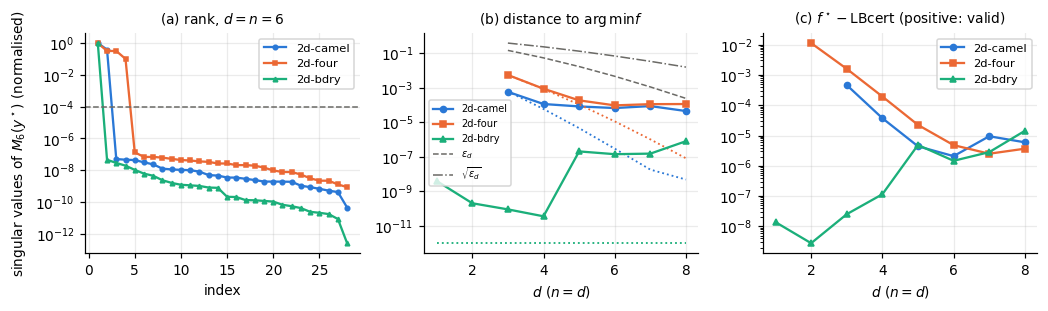

In [11]:
P2 = [P for P in PROBLEMS if P["p"] == 2]
fig, axs = plt.subplots(1, 3, figsize=(9.6, 2.9))
ax = axs[0]
for i, P in enumerate(P2):
    d = 6; r = RUNS[P["key"], d, d]
    sv = svals(mom_mat(r["y"], 2, d)); ax.semilogy(np.arange(1, len(sv) + 1), sv / sv[0], color=COL[i], marker=MARK[i], ms=3, label=P["key"])
ax.axhline(RANK_TOL, color=GREY, ls="--", lw=1)
ax.set_xlabel("index"); ax.set_ylabel("singular values of $M_6(y^\\star)$ (normalised)"); ax.set_title("(a) rank, $d=n=6$"); ax.legend()
ax = axs[1]
for i, P in enumerate(P2):
    ds = [d for d in range(P["dmin"], P["dmax"] + 1) if "atoms" in EXT[P["key"], d, d]]
    ax.semilogy(ds, [EXT[P["key"], d, d]["Hf"] for d in ds], color=COL[i], marker=MARK[i], label=P["key"])
    ax.semilogy(ds, [max(hausdorff(SUR[P["key"], d]["argd"], P["argmin"]), 1e-12) for d in ds], color=COL[i], ls=":", lw=1.2)
dd = np.arange(3, 9); ax.semilogy(dd, [eps_d(2.0, d) for d in dd], color=GREY, ls="--", lw=1, label=r"$\varepsilon_d$")
ax.semilogy(dd, [math.sqrt(eps_d(2.0, d)) for d in dd], color=GREY, ls="-.", lw=1, label=r"$\sqrt{\varepsilon_d}$")
ax.set_xlabel("$d$ ($n=d$)"); ax.set_title("(b) distance to $\\arg\\min f$"); ax.legend(fontsize=6.5)
ax = axs[2]
for i, P in enumerate(PROBLEMS[3:]):
    ds = range(P["dmin"], P["dmax"] + 1)
    ax.semilogy(list(ds), [max(P["fstar"] - EXT[P["key"], d, d]["LBcert"], 1e-16) for d in ds], color=COL[i], marker=MARK[i], label=P["key"])
ax.set_xlabel("$d$ ($n=d$)"); ax.set_title("(c) $f^\\star-$LBcert (positive: valid)"); ax.legend()
fig.tight_layout()
savefig(fig, "g1_flat")
plt.show()

## 5. Experiment 3: Remark 3

$\mathcal{X}=[0,1]$, $\omega=e^{-x^2/2}$, $q=1+x$, $f^\star=2/e$ at $x=1$. Three descriptions of the same set:
(A) $\{x\ge0,\ 1-x\ge0\}$ (Archimedean, linear), (B) (A) plus the ball constraint $1-x^2\ge0$,
(C) the single quadratic $x(1-x)\ge0$ (Archimedean, no ball constraint). The remark predicts $\rho_d=0$ for (A) and
$\rho_d\to2/e$ for (B). Here $f^\star_d=\min_{[0,1]}(1+x)/\theta_d=2/\theta_d(1)$ for $d\ge2$. We also print
$a_dy_{2d}$, the share of the normalisation carried by the top moment.

In [12]:
q_ball = {(0,): 1.0, (1,): 1.0}
DESC = {"A: {x, 1-x}": [{(1,): 1.0}, {(0,): 1.0, (1,): -1.0}],
        "B: {x, 1-x, 1-x^2}": [{(1,): 1.0}, {(0,): 1.0, (1,): -1.0}, {(0,): 1.0, (2,): -1.0}],
        "C: {x(1-x)}": [{(1,): 1.0, (2,): -1.0}]}
BALL = {}
xs01 = np.linspace(0, 1, 100001)[:, None]
print("f* = 2/e = %.10f" % (2 / math.e))
print("  d   f*_d        " + "".join("%-38s" % k for k in DESC))
for d in range(1, 11):
    fd = float((peval(q_ball, xs01) / theta_eval(xs01, d)).min())
    row = []
    for k, gs in DESC.items():
        r = solve_relax(q_ball, gs, 1, d, d, s=1.0)
        BALL[k, d] = r
        top = GAUSS["a"](d) * r["y"][2 * d] if r["y"] is not None else np.nan
        row.append("%+.7f a_d*y_2d=%.2f %-10s" % (r["value"], top, fmt_status(r)))
    BALL["fd", d] = fd
    print("%3d  %.7f   %s" % (d, fd, "  ".join(row)))
# the explicit point of Remark 3, y = (0,...,0,1/a_d): feasible for (A) with value 0 (and L_y(q) = y_0 + y_1 >= 0 on (A))
okpt = True
for d in range(1, 11):
    ypt = np.zeros(2 * d + 1); ypt[2 * d] = 1 / GAUSS["a"](d)
    mins = [np.linalg.eigvalsh(mom_mat(ypt, 1, d)).min()] + [np.linalg.eigvalsh((loc_op(1, d, g)[0] @ ypt).reshape(d, d)).min() for g in DESC["A: {x, 1-x}"]]
    okpt &= min(mins) >= 0 and abs(lin(1, d, theta(1, d)) @ ypt - 1) < 1e-12 and lin(1, d, q_ball) @ ypt == 0
check("Rem 3: y = (0,...,0,1/a_d) feasible for (A) with L_y(theta_d) = 1 and value 0, d = 1..10", okpt)
solvedA = [d for d in range(1, 11) if BALL["A: {x, 1-x}", d]["y"] is not None and abs(BALL["A: {x, 1-x}", d]["value"]) <= 1e-5]
print("   (A): solver value 0 (to 1e-5) for d in", solvedA, "; other d: solver failure or a spurious value (the optimiser has y_2d = d!)")
check("Rem 3: solver finds rho_d = 0 for (A) at d <= 6", all(d in solvedA for d in range(1, 7)))
check("Rem 3: rho_d -> 2/e with the ball constraint", abs(BALL["B: {x, 1-x, 1-x^2}", 10]["value"] - 2 / math.e) < 1e-5,
      "(rho_10 - 2/e = %.1e)" % (BALL["B: {x, 1-x, 1-x^2}", 10]["value"] - 2 / math.e))
check("single quadratic x(1-x) also gives rho_d -> 2/e", abs(BALL["C: {x(1-x)}", 10]["value"] - 2 / math.e) < 1e-5,
      "(rho_10 - 2/e = %.1e)" % (BALL["C: {x(1-x)}", 10]["value"] - 2 / math.e))

f* = 2/e = 0.7357588823
  d   f*_d        A: {x, 1-x}                           B: {x, 1-x, 1-x^2}                    C: {x(1-x)}                           


  1  1.0000000   -0.0000000 a_d*y_2d=1.00 CLA:optimal  +0.5000000 a_d*y_2d=0.50 CLA:optimal  +1.0000000 a_d*y_2d=0.25 CLA:optimal
  2  0.8000000   -0.0000000 a_d*y_2d=1.00 CLA:optimal  +0.8000000 a_d*y_2d=0.20 CLA:optimal  +0.8000000 a_d*y_2d=0.20 CLA:optimal
  3  0.7500000   +0.0000000 a_d*y_2d=1.00 CLA:optimal  +0.7500000 a_d*y_2d=0.06 CLA:optimal  +0.7500000 a_d*y_2d=0.06 CLA:optimal
  4  0.7384615   +0.0000000 a_d*y_2d=1.00 CLA:optimal  +0.7384615 a_d*y_2d=0.02 CLA:optimal  +0.7384615 a_d*y_2d=0.02 CLA:optimal
  5  0.7361963   +0.0000003 a_d*y_2d=1.00 CLA:opt_inacc  +0.7361963 a_d*y_2d=0.00 CLA:optimal  +0.7361963 a_d*y_2d=0.00 CLA:optimal
  6  0.7358201   -0.0000000 a_d*y_2d=1.00 CLA:solver_error/SCS:optimal  +0.7358201 a_d*y_2d=0.00 CLA:optimal  +0.7358201 a_d*y_2d=0.00 CLA:optimal


  7  0.7357664   +nan a_d*y_2d=nan CLA:solver_error/SCS:unbounded_inaccurate  +0.7357664 a_d*y_2d=0.00 CLA:opt_inacc  +0.7357664 a_d*y_2d=0.00 CLA:optimal


  8  0.7357597   +nan a_d*y_2d=nan CLA:solver_error/SCS:unbounded_inaccurate  +0.7357597 a_d*y_2d=0.00 CLA:optimal  +0.7357597 a_d*y_2d=0.00 CLA:optimal


  9  0.7357590   +0.7357533 a_d*y_2d=0.00 CLA:solver_error/SCS:opt_inacc  +0.7357590 a_d*y_2d=0.00 CLA:optimal  +0.7357590 a_d*y_2d=0.00 CLA:optimal
 10  0.7357589   +0.7357530 a_d*y_2d=0.00 CLA:opt_inacc  +0.7357589 a_d*y_2d=0.00 CLA:opt_inacc  +0.7357589 a_d*y_2d=0.00 CLA:optimal
[pass] Rem 3: y = (0,...,0,1/a_d) feasible for (A) with L_y(theta_d) = 1 and value 0, d = 1..10 
   (A): solver value 0 (to 1e-5) for d in [1, 2, 3, 4, 5, 6] ; other d: solver failure or a spurious value (the optimiser has y_2d = d!)
[pass] Rem 3: solver finds rho_d = 0 for (A) at d <= 6 
[pass] Rem 3: rho_d -> 2/e with the ball constraint (rho_10 - 2/e = 3.7e-08)
[pass] single quadratic x(1-x) also gives rho_d -> 2/e (rho_10 - 2/e = 1.7e-08)


saved ../figs/extra/g1_ball.pdf


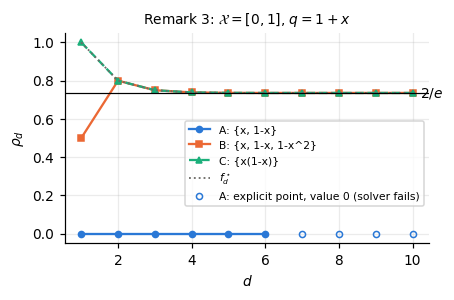

In [13]:
fig, ax = plt.subplots(figsize=(4.2, 2.8))
ds = np.arange(1, 11)
for i, k in enumerate(DESC):
    dk = solvedA if i == 0 else list(ds)          # (A): only the runs where the solver returned the value 0
    ax.plot(dk, [BALL[k, d]["value"] for d in dk], color=COL[i], marker=MARK[i], ls="-" if i < 2 else "--", label=k)
ax.plot(ds, [BALL["fd", d] for d in ds], color=GREY, ls=":", lw=1.2, label=r"$f^\star_d$")
dfail = [d for d in ds if d not in solvedA]
ax.plot(dfail, [0.0] * len(dfail), ls="none", marker="o", mfc="none", mec=COL[0], label="A: explicit point, value 0 (solver fails)")
ax.axhline(2 / math.e, color="k", lw=0.8)
ax.text(10.2, 2 / math.e, r"$2/e$", va="center")
ax.set_xlabel("$d$"); ax.set_ylabel(r"$\rho_d$"); ax.set_title(r"Remark 3: $\mathcal{X}=[0,1]$, $q=1+x$")
ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=7, loc="center right", bbox_to_anchor=(1.0, 0.38))
fig.tight_layout()
savefig(fig, "g1_ball")
plt.show()

## 6. Experiment 4: the non-compact carrier $\mathbb R^p$

$\rho_d=\min\{L_y(q):L_y(\theta_d)=1,\ M_d(y)\succeq0\}$ with no localizing constraint (Proposition 9), unscaled
variables ($s=1$). On $\mathbb R^p$, $f=\omega^2q\to0$ at infinity, so $f^\star\le0$ whenever it is attained. Along the
Clarabel optimisers we monitor the tail in (T),
$$T(r;d)=\sum_{k=r+1}^{d}a_kL_{y^{(d)}}(\|x\|^{2k}),\qquad \text{and}\qquad \sup_{r<d\le d_{\max}}T(r;d),$$
which should tend to $0$ as $r$ grows if (T) holds. The top term $a_dL_{y^{(d)}}(\|x\|^{2d})$ is the share of the
normalisation carried by the highest degree (for $d=1$ and $q=-x^2$ the surrogate infimum is not attained, and all the
mass sits there). The surrogate $f^\star_d=\inf_{\mathbb R^p}q/\theta_d$ is computed on $[-12,12]^p$; a minimiser on the
edge of that box is flagged as `edge`.

In [14]:
NC = [dict(key="R-two",   p=1, q={(4,): 1.0, (2,): -2.0}, dmax=12),
      dict(key="R-negsq", p=1, q={(2,): -1.0}, dmax=12),
      dict(key="R-multi", p=1, q={(6,): 1.0, (4,): -3.0, (2,): 2.0, (1,): 0.6}, dmax=12),
      dict(key="R2-camel", p=2, q=CAMEL, dmax=8),
      dict(key="R2-four",  p=2, q=FOUR, dmax=8)]
NCR = {}
t0 = time.time()
for P in NC:
    q, p = P["q"], P["p"]
    P["fstar"], P["argmin"], _ = grid_minimisers(lambda X: omega2(X) * peval(q, X), [-6] * p, [6] * p, NGRID[p])
    P["dmin"] = max(1, math.ceil(pdeg(q) / 2))
    print("\n== %s  f* = %+.10f  argmin = %s" % (P["key"], P["fstar"], np.round(P["argmin"], 4).tolist()))
    print("  d   rho_d-f*    rho_d-f*_d   top a_d L(|x|^2d)   T(r;d) for r = 0,1,2,..   flat t/r   status")
    for d in range(P["dmin"], P["dmax"] + 1):
        L = 12.0
        fd, argd, _ = grid_minimisers(lambda X: peval(q, X) / theta_eval(X, d), [-L] * p, [L] * p, 400001 if p == 1 else 801)
        edge = bool(np.any(np.abs(argd) >= L - 1e-6))
        r = solve_relax(q, [], p, d, d, s=1.0)
        e = dict(r=r, fd=fd, edge=edge)
        if r["y"] is not None:
            mk = sqnorm_moments(r["y"], p, d, d)
            e["T"] = np.array([mk[j + 1:].sum() for j in range(d)])
            e["top"] = mk[-1]
            e["flat"] = flat_truncation(r["y"], p, d)
        NCR[P["key"], d] = e
        print("%3d  %+10.2e  %+10.2e%s  %10.2e        %s   %s/%s  %s" % (d, r["value"] - P["fstar"], r["value"] - fd, " edge" if edge else "     ",
              e.get("top", np.nan), np.array2string(e["T"][:6], precision=1, separator=" ") if "T" in e else "-",
              e["flat"][0] if "flat" in e else "-", e["flat"][1] if "flat" in e else "-", fmt_status(r)))
print("\nexperiment 4: %.1f s" % (time.time() - t0))
for P in NC:
    ds = range(P["dmin"], P["dmax"] + 1)
    supT = [max(NCR[P["key"], d]["T"][rr] for d in ds if d > rr) for rr in range(P["dmax"] - 1)]
    P["supT"] = supT
    check("%s: rho_d -> f* (|rho_dmax - f*| < 1e-5)" % P["key"], abs(NCR[P["key"], P["dmax"]]["r"]["value"] - P["fstar"]) < 1e-5,
          "(%.1e)" % abs(NCR[P["key"], P["dmax"]]["r"]["value"] - P["fstar"]))
    print("     sup_{d>r} T(r;d), r = 0..%d:" % (P["dmax"] - 2), np.array2string(np.array(supT), precision=1))


== R-two  f* = -0.4611587920  argmin = [[-0.7654], [0.7654]]
  d   rho_d-f*    rho_d-f*_d   top a_d L(|x|^2d)   T(r;d) for r = 0,1,2,..   flat t/r   status


  2   -1.10e-02   +5.12e-09         1.06e-01        [0.4 0.1]   2/2  CLA:optimal


  3   -1.45e-03   +1.17e-09         1.91e-02        [0.4 0.1 0. ]   2/2  CLA:optimal
  4   -1.64e-04   +1.91e-09         2.74e-03        [0.4 0.1 0.  0. ]   2/2  CLA:optimal


  5   -1.57e-05   -9.30e-10         3.20e-04        [4.4e-01 1.2e-01 2.2e-02 3.1e-03 3.2e-04]   2/2  CLA:optimal


  6   -1.30e-06   +6.00e-12         3.12e-05        [4.4e-01 1.2e-01 2.2e-02 3.1e-03 3.5e-04 3.1e-05]   2/2  CLA:optimal
  7   -8.47e-08   +9.68e-09         2.64e-06        [4.4e-01 1.2e-01 2.2e-02 3.1e-03 3.5e-04 3.4e-05]   2/2  CLA:optimal


...

  2   -1.13e-02   -8.10e-09         1.22e-01        [0.5 0.1]   None/None  CLA:optimal
  3   -1.59e-03   -6.69e-09         2.37e-02        [0.5 0.1 0. ]   3/4  CLA:optimal


  4   -1.94e-04   +9.33e-10         3.67e-03        [0.5 0.1 0.  0. ]   3/4  CLA:optimal
  5   -2.02e-05   -2.30e-09         4.66e-04        [4.7e-01 1.3e-01 2.7e-02 4.1e-03 4.7e-04]   3/4  CLA:optimal


  6   -1.82e-06   +1.76e-10         4.95e-05        [4.7e-01 1.3e-01 2.7e-02 4.2e-03 5.1e-04 5.0e-05]   3/4  CLA:optimal


  7   -1.41e-07   +2.98e-09         4.52e-06        [4.7e-01 1.3e-01 2.7e-02 4.2e-03 5.2e-04 5.4e-05]   3/4  CLA:optimal


  8   -9.25e-09   +8.50e-10         3.63e-07        [4.7e-01 1.3e-01 2.7e-02 4.2e-03 5.2e-04 5.4e-05]   3/4  CLA:optimal

experiment 4: 7.5 s
[pass] R-two: rho_d -> f* (|rho_dmax - f*| < 1e-5) (7.4e-09)
     sup_{d>r} T(r;d), r = 0..10: [4.5e-01 1.2e-01 2.2e-02 3.1e-03 3.5e-04 3.4e-05 2.9e-06 2.4e-07 4.7e-08
 1.6e-08 1.2e-08]
[pass] R-negsq: rho_d -> f* (|rho_dmax - f*| < 1e-5) (1.2e-08)
     sup_{d>r} T(r;d), r = 0..10: [1.0e+00 2.9e-01 8.0e-02 1.9e-02 3.7e-03 5.9e-04 8.3e-05 1.0e-05 1.2e-06
 1.5e-07 4.5e-08]
[pass] R-multi: rho_d -> f* (|rho_dmax - f*| < 1e-5) (1.6e-07)
     sup_{d>r} T(r;d), r = 0..10: [7.3e-01 3.8e-01 1.5e-01 4.4e-02 1.1e-02 2.3e-03 4.3e-04 6.9e-05 1.0e-05
 1.5e-06 3.5e-07]
[pass] R2-camel: rho_d -> f* (|rho_dmax - f*| < 1e-5) (4.0e-08)
     sup_{d>r} T(r;d), r = 0..6: [3.2e-01 5.9e-02 7.3e-03 7.0e-04 5.4e-05 3.7e-06 4.0e-07]
[pass] R2-four: rho_d -> f* (|rho_dmax - f*| < 1e-5) (9.3e-09)
     sup_{d>r} T(r;d), r = 0..6: [4.8e-01 1.3e-01 2.7e-02 4.2e-03 5.2e-04 5.4e

saved ../figs/extra/g1_noncompact.pdf


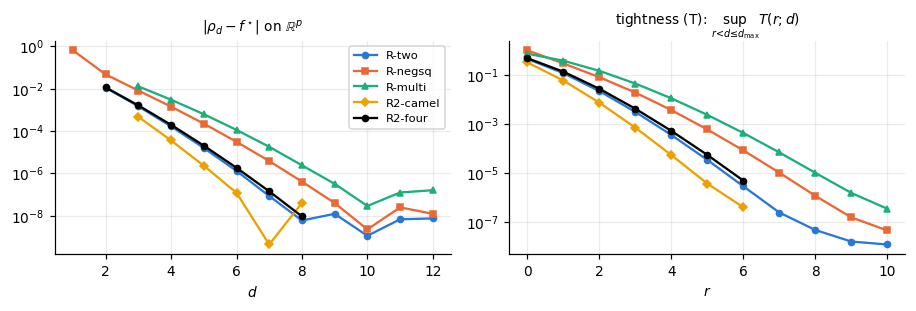

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(8.4, 2.9))
for i, P in enumerate(NC):
    ds = list(range(P["dmin"], P["dmax"] + 1))
    c = COL[i % 4] if i < 4 else "k"
    axs[0].semilogy(ds, [max(abs(NCR[P["key"], d]["r"]["value"] - P["fstar"]), 1e-16) for d in ds], color=c, marker=MARK[i % 4], label=P["key"])
    axs[1].semilogy(range(len(P["supT"])), np.maximum(P["supT"], 1e-16), color=c, marker=MARK[i % 4], label=P["key"])
axs[0].set_xlabel("$d$"); axs[0].set_title(r"$|\rho_d-f^\star|$ on $\mathbb{R}^p$"); axs[0].legend()
axs[1].set_xlabel("$r$"); axs[1].set_title(r"tightness (T): $\sup_{r<d\leq d_{\max}}T(r;d)$")
fig.tight_layout()
savefig(fig, "g1_noncompact")
plt.show()

## 7. Experiment 5: general objectives and the two approximation errors

$f$ is not of the form $\omega^2q$. On $\mathcal{X}=[-1.5,1.5]$ we take $q$ the Chebyshev interpolant of degree $2d$ of
$f\,e^{x^2}$, so that $\delta_q=\|f-\omega^2q\|_{\infty,\mathcal{X}}$ and $\varepsilon_d$ both decrease with $d$, and solve
$\rho_{d,d}$. Proposition 14 asserts $|f^\star_d-f^\star|\le\delta_q+\|q\|_\infty\varepsilon_d$ and, for any minimiser
$x$ of $q/\theta_d$, $f(x)\le f^\star+2\delta_q+2\|q\|_\infty\varepsilon_d$; we test the second on the extracted atoms.
Two objectives: a smooth one, $f=\sin 3x+\tfrac12\cos5x$, and a Lipschitz one with a kink,
$f=|x-0.5|-0.4\cos4x$, for which $\delta_q$ decays only algebraically. $d\le10$: at $d=12$ the monomial
coefficients of the interpolant of the kinked function reach $10^6$ and Clarabel returned a wrong value in a
preliminary run.

In [16]:
GEN = {"smooth": lambda x: np.sin(3 * x) + 0.5 * np.cos(5 * x),
       "kink":   lambda x: np.abs(x - 0.5) - 0.4 * np.cos(4 * x)}
R = 1.5; R2g = R * R
xs = np.linspace(-R, R, 200001)
TWO = {}
for name, f in GEN.items():
    fstar, argf, _ = grid_minimisers(lambda X: f(X[:, 0]), [-R], [R], NGRID[1])
    print("\n== %s: f* = %+.10f at %s" % (name, fstar, np.round(argf[:, 0], 5)))
    print("  d  deg q   delta_q   ||q||    ||q||eps_d  |fd-f*|   bound1    f(x_i)-f*   bound2    rho-fd     status")
    for d in range(2, 11):
        cu = Cheb.chebinterpolate(lambda u: f(R * u) * np.exp((R * u) ** 2), 2 * d)
        pu = Cheb.cheb2poly(cu)
        q = {(k,): float(pu[k] / R ** k) for k in range(len(pu))}
        qv = peval(q, xs[:, None]); fv = f(xs)
        dq = float(np.abs(fv - np.exp(-xs ** 2) * qv).max()); qinf = float(np.abs(qv).max())
        fd, argd, _ = grid_minimisers(lambda X: peval(q, X) / theta_eval(X, d), [-R], [R], NGRID[1])
        r = solve_relax(q, [{(0,): R2g, (2,): -1.0}], 1, d, d, s=R)
        t, rk, gap = flat_truncation(r["y"], 1, d) if r["y"] is not None else (None, None, None)
        at, w = extract_atoms(r["y"], 1, t, rk) if t else (None, None)
        gapf = float(np.max(f(at[:, 0] * R)) - fstar) if at is not None else np.nan
        b1 = dq + qinf * eps_d(R2g, d); b2 = 2 * b1
        TWO[name, d] = dict(dq=dq, qinf=qinf, fd=fd, fstar=fstar, gapf=gapf, b1=b1, b2=b2, rho=r["value"], status=fmt_status(r))
        print("%3d  %3d   %8.1e  %6.2f   %8.1e  %8.1e  %8.1e   %9.1e  %8.1e  %+8.1e   %s" % (d, pdeg(q), dq, qinf, qinf * eps_d(R2g, d),
              abs(fd - fstar), b1, gapf, b2, r["value"] - fd, fmt_status(r)))
    ds = range(2, 11)
    check("%s: |f*_d - f*| <= delta_q + ||q|| eps_d" % name, all(abs(TWO[name, d]["fd"] - fstar) <= TWO[name, d]["b1"] for d in ds))
    check("%s: f(x_i) <= f* + 2 delta_q + 2||q|| eps_d" % name, all(TWO[name, d]["gapf"] <= TWO[name, d]["b2"] for d in ds))


== smooth: f* = -1.4714036579 at [-0.58442]
  d  deg q   delta_q   ||q||    ||q||eps_d  |fd-f*|   bound1    f(x_i)-f*   bound2    rho-fd     status
  2    4    8.7e-01   12.39    4.8e+00   1.9e-02   5.7e+00     1.4e-02   1.1e+01  -7.7e-09   CLA:optimal


  3    6    3.9e-02   11.02    2.1e+00   1.6e-02   2.1e+00     8.8e-04   4.3e+00  -1.9e-09   CLA:optimal


  4    8    1.6e-02   10.91    8.5e-01   1.7e-03   8.7e-01     5.5e-06   1.7e+00  -1.9e-08   CLA:opt_inacc


  5   10    2.5e-03   10.92    3.0e-01   5.4e-04   3.0e-01     8.0e-07   6.0e-01  -8.9e-07   CLA:opt_inacc


  6   12    1.8e-04   10.92    9.1e-02   8.6e-05   9.2e-02     3.6e-07   1.8e-01  -1.8e-07   CLA:opt_inacc


...

  6   12    1.0e-01   15.33    1.3e-01   2.3e-02   2.3e-01     5.4e-04   4.6e-01  +1.4e-06   CLA:opt_inacc


  7   14    8.3e-02   15.33    3.5e-02   2.8e-04   1.2e-01     8.6e-05   2.4e-01  +1.5e-06   CLA:opt_inacc


  8   16    3.7e-02   15.33    8.4e-03   1.6e-02   4.6e-02     1.1e-03   9.2e-02  +2.9e-05   CLA:opt_inacc


  9   18    4.6e-02   15.34    1.9e-03   1.3e-02   4.8e-02     2.7e-02   9.6e-02  -1.1e-09   CLA:solver_error/SCS:optimal


 10   20    5.2e-02   15.33    3.7e-04   7.0e-03   5.3e-02     5.8e-03   1.1e-01  +9.6e-11   CLA:solver_error/SCS:optimal
[pass] kink: |f*_d - f*| <= delta_q + ||q|| eps_d 
[pass] kink: f(x_i) <= f* + 2 delta_q + 2||q|| eps_d 


saved ../figs/extra/g1_twoerror.pdf


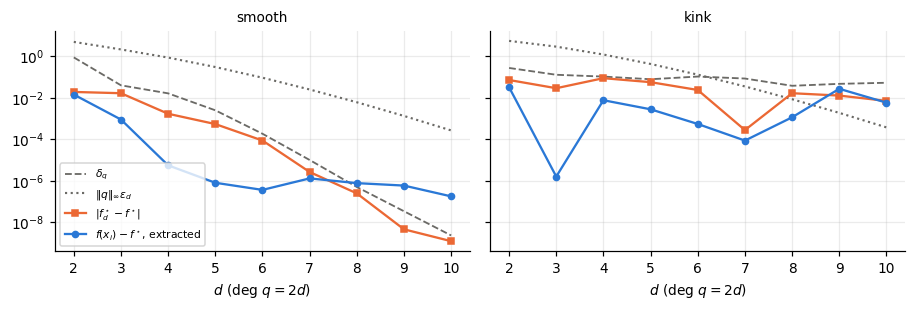

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(8.4, 2.9), sharey=True)
for ax, name in zip(axs, GEN):
    ds = np.arange(2, 11)
    ax.semilogy(ds, [TWO[name, d]["dq"] for d in ds], color=GREY, ls="--", lw=1.2, label=r"$\delta_q$")
    ax.semilogy(ds, [TWO[name, d]["qinf"] * eps_d(R2g, d) for d in ds], color=GREY, ls=":", lw=1.4, label=r"$\|q\|_\infty\varepsilon_d$")
    ax.semilogy(ds, [max(abs(TWO[name, d]["fd"] - TWO[name, d]["fstar"]), 1e-16) for d in ds], color=COL[1], marker="s", label=r"$|f^\star_d-f^\star|$")
    ax.semilogy(ds, [max(TWO[name, d]["gapf"], 1e-16) for d in ds], color=COL[0], marker="o", label=r"$f(x_i)-f^\star$, extracted")
    ax.set_title(name); ax.set_xlabel("$d$ (deg $q=2d$)")
axs[0].legend(fontsize=7)
fig.tight_layout()
savefig(fig, "g1_twoerror")
plt.show()

## 8. Experiment 6: a weight with $\omega^{-2}$ polynomial

With $\omega^{-2}=1+\|x\|^2$ ($g(t)=1+t$ in **(W)**: $a_0=a_1=1$, $a_k=0$ for $k\ge2$) one has $\theta_d=\omega^{-2}$ for $d\ge1$,
and Theorem 10 predicts exact recovery: $\rho_d=f^\star$ and $\mu^\star=\omega^{-2}\nu^\star\in\mathscr P(\mathcal{X})$ supported on
$\arg\min f$. Test: $f=\text{camel}/(1+\|x\|^2)$ on $[-1,1]^2$ with the same constraints as `2d-camel`.

In [18]:
fC = lambda X: omega2(X, CAUCHY) * peval(CAMEL, X)
fsC, argC, _ = grid_minimisers(fC, [-1, -1], [1, 1], NGRID[2])
print("f* = %+.10f  argmin = %s" % (fsC, np.round(argC, 5).tolist()))
for d in (3, 4, 5):
    r = solve_relax(CAMEL, BOX2, 2, d, d, s=1.0, W=CAUCHY)
    t, rk, gap = flat_truncation(r["y"], 2, d)
    at, w = extract_atoms(r["y"], 2, t, rk)
    mass = float(np.sum(w * (1 + sqnorm(at))))
    print("d=%d  rho_d - f* = %+.1e  lambda_d - f* = %+.1e  flat t=%s rank=%s  H(atoms, argmin f) = %.1e  mass of mu* = %.8f  %s" % (
          d, r["value"] - fsC, r["lam"] - fsC, t, rk, hausdorff(at, argC), mass, fmt_status(r)))
check("Cauchy weight: rho_d = f* (exact case of Thm 10)", abs(r["value"] - fsC) < 1e-6, "(%.1e)" % abs(r["value"] - fsC))
check("Cauchy weight: mu* is a probability supported on argmin f", abs(mass - 1) < 1e-6 and hausdorff(at, argC) < 1e-3)

f* = -0.7019601641  argmin = [[-0.06912, 0.64725], [0.06912, -0.64725]]


d=3  rho_d - f* = -1.2e-07  lambda_d - f* = -9.6e-08  flat t=2 rank=2  H(atoms, argmin f) = 5.4e-05  mass of mu* = 1.00000006  CLA:opt_inacc
d=4  rho_d - f* = +1.1e-08  lambda_d - f* = +8.7e-09  flat t=2 rank=2  H(atoms, argmin f) = 7.0e-05  mass of mu* = 0.99999996  CLA:opt_inacc
d=5  rho_d - f* = -1.8e-08  lambda_d - f* = -1.8e-08  flat t=2 rank=2  H(atoms, argmin f) = 5.2e-05  mass of mu* = 1.00000009  CLA:opt_inacc
[pass] Cauchy weight: rho_d = f* (exact case of Thm 10) (1.8e-08)
[pass] Cauchy weight: mu* is a probability supported on argmin f 


## 9. Candidate figure for the paper

Three panels: (a) `2d-camel`, truncation error $|f^\star_d-f^\star|$, SDP error $|\rho_d-f^\star|$, the gap
$f^\star-\text{LBcert}$ of the validated bound, and the bound $\|q\|_\infty\varepsilon_d$ of Lemma 12; (b) Remark 3;
(c) the non-compact case, $|\rho_d-f^\star|$ and the tail $\sup_{d>r}T(r;d)$ for the planar camel on $\mathbb R^2$.

saved ../figs/extra/g1_summary.pdf


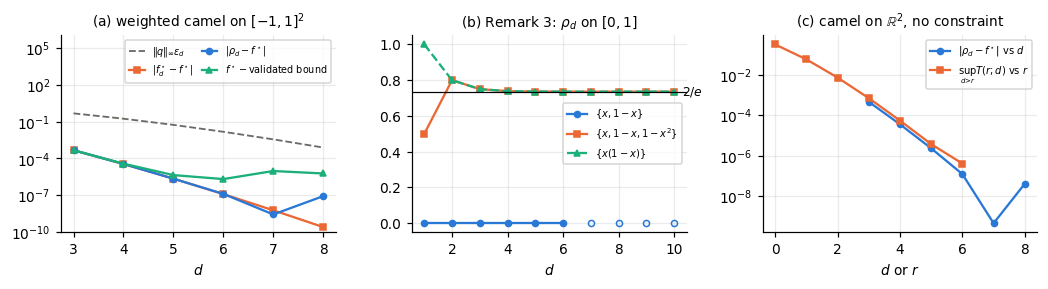

In [19]:
fig, axs = plt.subplots(1, 3, figsize=(9.6, 2.7))
P = PROBLEMS[3]; key, fs = P["key"], P["fstar"]; ds = np.arange(P["dmin"], P["dmax"] + 1)
ax = axs[0]
ax.semilogy(ds, [P["qinf"] * eps_d(P["R2"], d) for d in ds], color=GREY, ls="--", lw=1.2, label=r"$\|q\|_\infty\varepsilon_d$")
ax.semilogy(ds, [abs(SUR[key, d]["fd"] - fs) for d in ds], color=COL[1], marker="s", label=r"$|f^\star_d-f^\star|$")
ax.semilogy(ds, [abs(RUNS[key, d, d]["value"] - fs) for d in ds], color=COL[0], marker="o", label=r"$|\rho_d-f^\star|$")
ax.semilogy(ds, [fs - EXT[key, d, d]["LBcert"] for d in ds], color=COL[2], marker="^", label=r"$f^\star-$validated bound")
ax.set_xlabel("$d$"); ax.set_title("(a) weighted camel on $[-1,1]^2$"); ax.set_ylim(1e-10, 1e6)
ax.legend(fontsize=6.3, loc="upper right", ncol=2, handlelength=1.6, columnspacing=0.8)
ax = axs[1]
dsb = np.arange(1, 11)
for i, k in enumerate(DESC):
    dk = solvedA if i == 0 else list(dsb)
    ax.plot(dk, [BALL[k, d]["value"] for d in dk], color=COL[i], marker=MARK[i], ls="-" if i < 2 else "--",
            label={0: r"$\{x,1-x\}$", 1: r"$\{x,1-x,1-x^2\}$", 2: r"$\{x(1-x)\}$"}[i])
dfail = [d for d in dsb if d not in solvedA]
ax.plot(dfail, [0.0] * len(dfail), ls="none", marker="o", mfc="none", mec=COL[0])
ax.axhline(2 / math.e, color="k", lw=0.8); ax.text(10.3, 2 / math.e, r"$2/e$", va="center", fontsize=8)
ax.set_xlabel("$d$"); ax.set_title(r"(b) Remark 3: $\rho_d$ on $[0,1]$"); ax.legend(fontsize=6.5, loc="center right")
ax = axs[2]
Pn = NC[3]; dsn = list(range(Pn["dmin"], Pn["dmax"] + 1))
ax.semilogy(dsn, [abs(NCR[Pn["key"], d]["r"]["value"] - Pn["fstar"]) for d in dsn], color=COL[0], marker="o", label=r"$|\rho_d-f^\star|$ vs $d$")
ax.semilogy(range(len(Pn["supT"])), Pn["supT"], color=COL[1], marker="s", label=r"$\sup_{d>r}T(r;d)$ vs $r$")
ax.set_xlabel("$d$ or $r$"); ax.set_title(r"(c) camel on $\mathbb{R}^2$, no constraint"); ax.legend(fontsize=6.5)
fig.tight_layout()
savefig(fig, "g1_summary")
plt.show()

In [20]:
print("checks: %d passed, %d failed" % (sum(ok for _, ok, _ in CHECKS), sum(not ok for _, ok, _ in CHECKS)))
for name, ok, det in CHECKS:
    if not ok:
        print("  FAIL:", name, det)
statuses = {}
for r in list(RUNS.values()) + [v for k, v in BALL.items() if k[0] != "fd"] + [e["r"] for e in NCR.values()]:
    statuses[fmt_status(r)] = statuses.get(fmt_status(r), 0) + 1
print("solver statuses (experiments 1-4):", statuses)
print("total runtime: %.1f s" % (time.time() - T_START))

checks: 100 passed, 2 failed
  FAIL: rho_{d,n} <= f*_d (max excess 2.5e-06)
  FAIL: LB <= f* (Prop 7) (max LB-f* +2.5e-06)
solver statuses (experiments 1-4): {'CLA:optimal': 109, 'CLA:opt_inacc': 104, 'CLA:solver_error/SCS:optimal': 1, 'CLA:solver_error/SCS:unbounded_inaccurate': 2, 'CLA:solver_error/SCS:opt_inacc': 1}
total runtime: 80.6 s


## 10. Findings

Numbers refer to the stored run (Clarabel through cvxpy 1.9.1; runtime about one minute on a laptop). Throughout,
$\varepsilon_d=\max_{\mathcal{X}}(1-\omega^2\theta_d)$ as in Proposition 7, that is $\mathbb P(\mathrm{Poisson}(R^2)>d)$ on the carriers used here.

1. **Convergence (Theorem 8, Proposition 6).** All 141 SDPs of experiment 1 were solved (status `optimal` or
   `optimal_inaccurate`). On all six compact problems the relaxation is already exact at $n=d$: $|\rho_{d,n}-f^\star_d|\le7\times10^{-7}$
   (1-D) and $\le3\times10^{-6}$ (2-D) for every $(d,n)$, and $|\lambda_d-\rho_d|\le4.4\times10^{-8}$. Hence $\rho_d\to f^\star$ at the rate of
   $f^\star_d\to f^\star$, until the solver accuracy (about $10^{-7}$) is reached. $d\mapsto f^\star_d$ is monotone, increasing when $f^\star<0$ and
   decreasing when $f^\star>0$. The two `FAIL` lines come from one solve (`2d-bdry`, $d=8$, $n=9$, status `optimal_inaccurate`), whose
   value exceeds $f^\star_d$ by $2.5\times10^{-6}$ ($1.8\times10^{-5}$ relative), which is impossible in exact arithmetic; the uncorrected bound
   `LB` inherits the error (item 4).
2. **Truncation error (Lemma 12).** $|f^\star_d-f^\star|$ decays factorially and satisfies every inequality of Lemma 12. On the four
   problems with interior minimisers the bound $\|q\|_\infty\varepsilon_d$ is pessimistic by factors between $24$ and $2\times10^7$, growing
   with $d$. On `1d-bdry` and `2d-bdry` the factor is only $15$ to $66$: the minimiser sits where $1-\omega^2\theta_d$ is largest, and
   the bound loses only $\|q\|_\infty/|q(x^\star)|$ ($7$ and $5$) and the factor $\theta_d(x^\star)\le e^{R^2}$. The localised bound of Lemma 12
   is within a factor $1.48$ to $9.49$ of the error, and `local.est`, which keeps the factor $1/\theta_d$, within 10% ($1.000$ to $1.095$):
   the rate is governed by $\|x^\star\|^{2(d+1)}/(d+1)!$ at the minimisers, not by $R^{2(d+1)}/(d+1)!$ (for `2d-camel`, $\|x^\star\|^2=0.39$
   against $R^2=2$). The formula $d(\varepsilon)$ of Theorem 13 asks for $d=6$ to $8$ at $\varepsilon=10^{-2}$ and $d=9$ to $11$ at
   $\varepsilon=10^{-4}$, where $d=1$ to $4$ suffice.
3. **Flat truncation and extraction (Theorems 10 and 13).** A flat truncation is found in 140 of 141 runs, and in 53 of the 54 runs
   with $n=d$. The exception is `2d-four` at $d=n=2$: four atoms need $\operatorname{rank}M_{t-1}\ge4$, impossible for $t\le2$ in two
   variables; at $n=3$ the truncation is flat. The smallest flat $t$ is $1$, $2$, $3$ for one, two and four minimisers. The atoms
   coincide with the minimisers of $q/\theta_d$ up to $1.4\times10^{-4}$ for interior minimisers and $3\times10^{-6}$ for boundary ones (at an
   interior minimiser the SDP value is quadratic in the position error, so positions are accurate to about the square root of
   the solver accuracy). The contact residual $|q(x_i)-\lambda_d\theta_d(x_i)|$ is at most $6\times10^{-6}$. The proof of Theorem 10 gives
   $|f(x_i)-\lambda_d|=|\lambda_d|(1-\omega^2\theta_d)(x_i)\le|\lambda_d|\varepsilon_d$, with equality when an atom sits where $1-\omega^2\theta_d$ is
   largest: on `1d-bdry` and `2d-bdry` the measured ratio $|f(x_i)-\lambda_d|/(|\lambda_d|\varepsilon_d)$ is $0.98$ to $1.02$. At interior
   minimisers it is at most $0.67$, except for `1d-multi` at $d=12$ ($3.2$), where $|\lambda_d|\varepsilon_d=2\times10^{-7}$ is below the solver
   accuracy. The check therefore allows the slack `TOL_CHECK`. Without it the inequality fails in 12 of the 140 runs, by at most
   $7.9\times10^{-7}$ (the `2d-bdry` solve of item 1) and otherwise by at most $4.4\times10^{-7}$. The distance to $\arg\min f$ follows the
   shift of the surrogate minimisers down to the extraction floor, far inside the $O(\sqrt{\varepsilon_d})$ of Theorem 13.
4. **Validated lower bound (Proposition 7).** `LBcert` $\le f^\star$ in every run. The uncorrected `LB`, computed from the
   floating-point $\lambda_d$, exceeds $f^\star$ in 15 of 141 runs: in 10 of the 16 `2d-bdry` runs, by up to $2.5\times10^{-6}$, and
   elsewhere by at most $1.5\times10^{-8}$. The residual correction is therefore needed for the bound to hold in floating point.
   Since $\min_{\mathcal{X}}\omega^2\theta_d=1-\varepsilon_d$, the form $\lambda_d(1-\varepsilon_d)$ of Proposition 7 for $\lambda_d\ge0$ is `LB` itself
   (the columns `f*-LB` and `f*-LBeps` agree in every row). On the two boundary problems, whose minimiser sits where $\omega^2\theta_d$
   is smallest, it is within the solver accuracy of $f^\star$: $|f^\star-\text{LB}|\le6.4\times10^{-8}$ on `1d-bdry` and $\le6.8\times10^{-7}$ on
   `2d-bdry` at $n=d$. For $f^\star<0$, $\lambda_d<0$ and the bound is $\lambda_d$ itself.
5. **Non-isolated minimisers.** On the ring the value is still exact, but no flat truncation exists (rank $M_t=2t+1$). With the
   relative threshold `RANK_TOL` the ranks saturate at 11 and report a spurious flat truncation at $t=6$: the 12th and 13th singular
   values of the moment matrix of the circle measure are $6\times10^{-5}$ and $5\times10^{-5}$ in the monomial basis. The extraction
   then fails its sanity checks (moment residual $\ge0.2$ or atoms outside $\mathcal{X}$); a largest-gap rank rule finds no flat truncation.
6. **Remark 3.** (A) $\{x,1-x\}$: $\rho_d=0$ for $d\le6$; for $d\ge7$ Clarabel fails and SCS reports unbounded or a spurious value, since
   the optimiser $(0,\dots,0,1/a_d)$ has an entry $d!\ge5040$ (its feasibility is verified directly for $d\le10$). (B) adding $1-x^2$:
   $\rho_1=1/2$ and $\rho_d=f^\star_d=2/\theta_d(1)$ for $d\ge2$, so $\rho_d\downarrow2/e$. (C) the single quadratic $x(1-x)\ge0$, without the ball
   constraint, gives the same values for $d\ge2$ and $\rho_1=1$: the ball constraint is sufficient, not necessary.
7. **Non-compact carrier (Proposition 9).** On the five problems on $\mathbb R^p$, $\rho_d\to f^\star$ ($|\rho_{d_{\max}}-f^\star|\le2\times10^{-7}$)
   and $\sup_{d>r}T(r;d)$ decays factorially in $r$ ($4\times10^{-7}$ at $r=10$ in 1-D, $5\times10^{-6}$ at $r=6$ in 2-D), so (T) holds along the
   Clarabel optimisers. $\rho_d=\inf_{\mathbb R^p}q/\theta_d$ to $2\times10^{-7}$ at every $d$. For $q=-x^2$ and $d=1$ the surrogate infimum
   $-1$ is not attained, and the optimiser puts the whole normalisation on the top moment ($a_1L_y(x^2)=1$).
8. **Two approximation errors (Proposition 14).** Both inequalities hold for the smooth and the kinked objective. For the kinked
   one $\delta_q$ stalls at $4$ to $10\times10^{-2}$ and exceeds $\|q\|_\infty\varepsilon_d$ from $d=7$; Clarabel failed at $d=9,10$ and SCS was used.
9. **Polynomial $\omega^{-2}$ (Theorem 10, exact case).** With $\omega^{-2}=1+\|x\|^2$ ($\theta_d=\omega^{-2}$ and $\varepsilon_d=0$ for $d\ge1$),
   $\rho_d=f^\star$ to $1.2\times10^{-7}$, $\mu^\star$ has mass $1\pm10^{-7}$ and its atoms are within $7\times10^{-5}$ of $\arg\min f$.

## 11. Numbers quoted in the paper, and its figure

The subsection "A numerical illustration" at the end of Section 5 quotes the numbers printed by the next cell, all
computed from the runs above, and shows the figure drawn by the last cell, `../figs/fig_global_opt.pdf` (the three
panels of Section 9, without titles). The notation is the paper's: `eps_d` is $\varepsilon_d=\max_{\mathcal{X}}(1-\omega^2\theta_d)$,
which is $\mathbb P(\mathrm{Poisson}(2)>d)$ on $[-1,1]^2$, and the dashed line in the left panel is the bound
$\|q\|_{\infty,\mathcal{X}}\,\varepsilon_d$ of Lemma 12. The localised estimate `loc` of experiment 1 is
$\max_{x\in\{x^\star,x_d\}}|q(x)|\,(1-\omega^2\theta_d)(x)/\theta_d(x)$; the localised bound of Lemma 12, without the factor
$1/\theta_d(x)\le1$ (`loc_lemma` below, the same as `loc12` of experiment 1), is also compared with the error.

In [21]:
# numbers quoted in the paper (Section 5, "A numerical illustration")
def runs_of(P, only_nd=False):
    return [(d, n) for d in range(P["dmin"], P["dmax"] + 1) for n in range(d, d + (0 if only_nd else P["dn"]) + 1)]

print("experiment 1: %d SDPs; d <= %s, n - d <= %s" % (len(RUNS), sorted({P["dmax"] for P in PROBLEMS}), sorted({P["dn"] for P in PROBLEMS})))
print("Prop 6: max |lambda_d - rho_d| over all compact problems and d: %.1e" % max(
    abs(RUNS[P["key"], d, d]["lam"] - RUNS[P["key"], d, d]["value"]) for P in PROBLEMS for d, _ in runs_of(P, True)))
for p in (1, 2):
    Ps = [P for P in PROBLEMS if P["p"] == p]
    e_nd = max(abs(RUNS[P["key"], d, n]["value"] - SUR[P["key"], d]["fd"]) for P in Ps for d, n in runs_of(P, True))
    e_all = max(abs(RUNS[P["key"], d, n]["value"] - SUR[P["key"], d]["fd"]) for P in Ps for d, n in runs_of(P))
    print("p = %d: max |rho_{d,n} - f*_d| at n = d: %.1e;  over all n: %.1e" % (p, e_nd, e_all))
rat = [SUR[P["key"], d]["loc"] / abs(SUR[P["key"], d]["fd"] - P["fstar"]) for P in PROBLEMS for d, _ in runs_of(P, True)]
print("localised estimate / |f*_d - f*| over all problems and d: min %.3f, max %.3f (%d values)" % (min(rat), max(rat), len(rat)))
def loc_lemma(P, d):
    # max over the minimisers x of f and of q/theta_d of |q(x)| (1 - omega^2 theta_d)(x) = |q(x)| P(Poisson(||x||^2) > d)
    pts = list(P["argmin"]) + list(SUR[P["key"], d]["argd"])
    return max(abs(peval(P["q"], x[None, :])[0]) * float(poisson_tail(sqnorm(x[None, :]), d)[0]) for x in pts)
rat2 = [loc_lemma(P, d) / abs(SUR[P["key"], d]["fd"] - P["fstar"]) for P in PROBLEMS for d, _ in runs_of(P, True)]
print("same without the factor 1/theta_d (localised bound of Lemma 12) / |f*_d - f*|: min %.2f, max %.2f" % (min(rat2), max(rat2)))
Pc = PROBLEMS[3]
print("%s: ||x*||^2 = %.2f, R^2 = %.0f; |f*_d - f*| = %.1e at d = %d, %.1e at d = %d" % (
    Pc["key"], sqnorm(Pc["argmin"]).max(), Pc["R2"], abs(SUR[Pc["key"], Pc["dmin"]]["fd"] - Pc["fstar"]), Pc["dmin"],
    abs(SUR[Pc["key"], Pc["dmax"]]["fd"] - Pc["fstar"]), Pc["dmax"]))

allr = [(P, d, n) for P in PROBLEMS for d, n in runs_of(P)]
ndd = [(P, d, n) for P, d, n in allr if n == d]
flat = lambda P, d, n: "atoms" in EXT[P["key"], d, n]
print("flat truncation with extraction: %d of %d runs at n = d, %d of %d overall; without: %s" % (
    sum(flat(*x) for x in ndd), len(ndd), sum(flat(*x) for x in allr), len(allr),
    [(P["key"], d, n) for P, d, n in allr if not flat(P, d, n)]))
for s in sorted({len(P["argmin"]) for P in PROBLEMS}):
    ts = sorted({EXT[P["key"], d, n]["t"] for P, d, n in allr if flat(P, d, n) and len(P["argmin"]) == s})
    print("   %d global minimiser(s): smallest flat order t = %s" % (s, ts))
ext = [EXT[P["key"], d, n] for P, d, n in allr if flat(P, d, n)]
print("at the flat order: smallest ratio s_r/s_{r+1} = %.1e (rank threshold %.0e); atoms in X: %s; max distance to the"
      " minimisers of q/theta_d: %.1e" % (min(e["gap"] for e in ext), RANK_TOL, all(e["inX"] for e in ext), max(e["Hs"] for e in ext)))

lb = [(EXT[P["key"], d, n], P["fstar"]) for P, d, n in allr if "LB" in EXT[P["key"], d, n]]
exc = [e["LB"] - fs for e, fs in lb]
print("Prop 7 bound from the numerical lambda_d: above f* in %d of %d runs, by at most %.1e" % (
    sum(x > 0 for x in exc), len(exc), max(exc)))
print("   with the residual correction: <= f* in %d of %d runs; the correction is at most %.1e" % (
    sum(e["LBcert"] <= fs for e, fs in lb), len(lb), max(e["LB"] - e["LBcert"] for e, _ in lb)))

okres = [res for _, _, _, _, ok, res in spurious if ok]
print("ring: largest-gap rank 2t+1 for all t < n in %d of %d runs, no flat truncation under that rule: %s; the threshold rule"
      " gives %d spurious flat truncations (t = %s), %d with atoms outside X, the others with moment residual >= %.1f" % (
    ring_2t1, ring_runs, ring_nogapflat, len(spurious), sorted({s[2] for s in spurious}),
    sum(not s[4] for s in spurious), min(okres)))

th1 = lambda d: sum(1 / math.factorial(k) for k in range(d + 1))
for k in list(DESC)[1:]:
    print("Rem 3, %s: rho_1 = %.4f; max_{2<=d<=10} |rho_d - 2/theta_d(1)| = %.1e" % (
        k, BALL[k, 1]["value"], max(abs(BALL[k, d]["value"] - 2 / th1(d)) for d in range(2, 11))))
print("Rem 3, A: solver value 0 for d in %s; explicit point of value 0 verified for d = 1..10" % solvedA)

Pn = NC[3]
print("%s: |rho_%d - f*| = %.1e; sup_{d>r} T(r;d) = %s for r = 0..%d" % (
    Pn["key"], Pn["dmax"], abs(NCR[Pn["key"], Pn["dmax"]]["r"]["value"] - Pn["fstar"]),
    np.array2string(np.array(Pn["supT"]), precision=1), len(Pn["supT"]) - 1))
print("R^p, all five tests: max |rho_dmax - f*| = %.1e" % max(abs(NCR[P["key"], P["dmax"]]["r"]["value"] - P["fstar"]) for P in NC))

sts = [fmt_status(r) for r in list(RUNS.values()) + [v for k, v in BALL.items() if k[0] != "fd"] + [e["r"] for e in NCR.values()]]
print("experiments 1-4: %d solves, Clarabel final status optimal_inaccurate in %d" % (len(sts), sum(s == "CLA:opt_inacc" for s in sts)))


experiment 1: 141 SDPs; d <= [8, 12], n - d <= [1, 2]
Prop 6: max |lambda_d - rho_d| over all compact problems and d: 4.4e-08
p = 1: max |rho_{d,n} - f*_d| at n = d: 6.6e-07;  over all n: 6.6e-07
p = 2: max |rho_{d,n} - f*_d| at n = d: 6.7e-07;  over all n: 2.5e-06
localised estimate / |f*_d - f*| over all problems and d: min 1.000, max 1.095 (54 values)
same without the factor 1/theta_d (localised bound of Lemma 12) / |f*_d - f*|: min 1.48, max 9.49
2d-camel: ||x*||^2 = 0.39, R^2 = 2; |f*_d - f*| = 4.6e-04 at d = 3, 2.6e-10 at d = 8
flat truncation with extraction: 53 of 54 runs at n = d, 140 of 141 overall; without: [('2d-four', 2, 2)]
   1 global minimiser(s): smallest flat order t = [1]
   2 global minimiser(s): smallest flat order t = [2]
   4 global minimiser(s): smallest flat order t = [3]
at the flat order: smallest ratio s_r/s_{r+1} = 4.0e+05 (rank threshold 1e-04); atoms in X: True; max distance to the minimisers of q/theta_d: 1.4e-04
Prop 7 bound from the numerical lambda_d:

saved ../figs/fig_global_opt.pdf


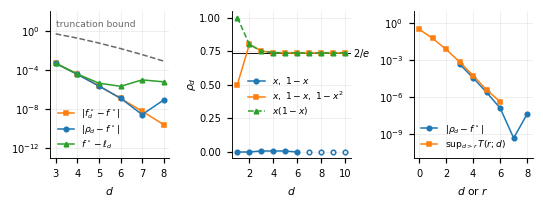

In [22]:
# the figure of the paper: ../figs/fig_global_opt.pdf (no titles; panels described in the caption)
def paper_fig_data():
    P = PROBLEMS[3]; key, fs = P["key"], P["fstar"]; ds = list(range(P["dmin"], P["dmax"] + 1))
    left = dict(d=ds, bound=[P["qinf"] * eps_d(P["R2"], d) for d in ds],
                trunc=[abs(SUR[key, d]["fd"] - fs) for d in ds], relax=[abs(RUNS[key, d, d]["value"] - fs) for d in ds],
                valid=[fs - EXT[key, d, d]["LBcert"] for d in ds])
    dsb = list(range(1, 11))
    centre = dict(d=dsb, dA=solvedA, A=[BALL[list(DESC)[0], d]["value"] for d in solvedA],
                  B=[BALL[list(DESC)[1], d]["value"] for d in dsb], C=[BALL[list(DESC)[2], d]["value"] for d in dsb],
                  dfail=[d for d in dsb if d not in solvedA])
    Pn = NC[3]; dsn = list(range(Pn["dmin"], Pn["dmax"] + 1))
    right = dict(d=dsn, relax=[abs(NCR[Pn["key"], d]["r"]["value"] - Pn["fstar"]) for d in dsn],
                 r=list(range(len(Pn["supT"]))), supT=list(Pn["supT"]))
    return dict(left=left, centre=centre, right=right)

def paper_fig(D, path):
    rc = {"font.size": 7, "axes.labelsize": 7, "xtick.labelsize": 6.5, "ytick.labelsize": 6.5, "legend.fontsize": 6,
          "lines.linewidth": 1.0, "lines.markersize": 3, "axes.linewidth": 0.6, "axes.spines.top": False,
          "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
          "legend.handlelength": 1.8, "legend.borderpad": 0.3, "legend.labelspacing": 0.25, "legend.frameon": False}
    with plt.rc_context(rc):
        fig, axs = plt.subplots(1, 3, figsize=(4.8, 1.75))
        L, Cc, Rt = D["left"], D["centre"], D["right"]
        ax = axs[0]
        ax.semilogy(L["d"], L["bound"], color=GREY, ls="--")
        ax.text(L["d"][0], 1.5, "truncation bound", color=GREY, fontsize=6, va="bottom")
        ax.semilogy(L["d"], L["trunc"], color="C1", marker="s", label=r"$|f^\star_d-f^\star|$")
        ax.semilogy(L["d"], L["relax"], color="C0", marker="o", label=r"$|\rho_d-f^\star|$")
        ax.semilogy(L["d"], L["valid"], color="C2", marker="^", label=r"$f^\star-\ell_d$")
        ax.set_xlabel("$d$"); ax.set_ylim(1e-13, 1e2); ax.set_xticks(L["d"])
        ax.set_yticks([1e0, 1e-4, 1e-8, 1e-12]); ax.minorticks_off()
        ax.legend(loc="lower left")
        ax = axs[1]
        ax.plot(Cc["dA"], Cc["A"], color="C0", marker="o", label=r"$x,\ 1-x$")
        ax.plot(Cc["dfail"], [0.0] * len(Cc["dfail"]), ls="none", marker="o", mfc="none", mec="C0")
        ax.plot(Cc["d"], Cc["B"], color="C1", marker="s", label=r"$x,\ 1-x,\ 1-x^2$")
        ax.plot(Cc["d"], Cc["C"], color="C2", marker="^", ls="--", label=r"$x(1-x)$")
        ax.axhline(2 / math.e, color="k", lw=0.6, zorder=0)
        ax.text(10.6, 2 / math.e, r"$2/e$", va="center", ha="left", fontsize=6.5, clip_on=False)
        ax.set_xlabel("$d$"); ax.set_ylabel(r"$\rho_d$", labelpad=1); ax.set_ylim(-0.05, 1.05); ax.set_xticks([2, 4, 6, 8, 10])
        ax.legend(loc="center right", bbox_to_anchor=(1.0, 0.42))
        ax = axs[2]
        ax.semilogy(Rt["d"], Rt["relax"], color="C0", marker="o", label=r"$|\rho_d-f^\star|$")
        ax.semilogy(Rt["r"], Rt["supT"], color="C1", marker="s", label=r"$\mathrm{sup}_{d>r}\,T(r;d)$")
        ax.set_xlabel("$d$ or $r$"); ax.set_xticks(range(0, 9, 2)); ax.minorticks_off()
        ax.set_ylim(1e-11, 1e1); ax.set_yticks([1e0, 1e-3, 1e-6, 1e-9])
        ax.legend(loc="lower left")
        fig.tight_layout(pad=0.3, w_pad=0.8)
        fig.savefig(path, bbox_inches="tight", pad_inches=0.02)
        if PNGDIR:
            os.makedirs(PNGDIR, exist_ok=True)
            fig.savefig(os.path.join(PNGDIR, "fig_global_opt.png"), bbox_inches="tight", pad_inches=0.02, dpi=300)
    print("saved", path)
    return fig

fig = paper_fig(paper_fig_data(), os.path.join("..", "figs", "fig_global_opt.pdf"))
plt.show()
